# **Verify 3.93e-8**

In [ ]:
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import openpyxl
import optax

import jax.numpy as jnp

import copy
import pickle

# Problem parameters
kappa = 3.93e-8      # thermal diffusivity [m^2/s]. Intial guess for the inverse problem (Spohn's value). We will learn this parameter.
depth = 0.4           # domain depth [m]
sol_seconds = 88775.244  # one sol [s]

avg_bottom_temp = 225.6  # average bottom temperature (K)
mole_depth = 0.094  # representative depth for diurnal signal [m]

# TEM-A Sol 1202 = mole temperature over one sol (the warmest sol sampled)
# RAD Sol 511   = surface temperature from radiometer (Spohn's proxy for sol 1202)

wb_diurnal = openpyxl.load_workbook(
    '../resources/data/Mars Soil Temperatures and Thermal Properties from Diurnal Wave data.xlsx',
    data_only=True
)

# --- Mole temperature (TEM-A Sol 1202) ---
ws_tem = wb_diurnal['TEM-A Sol 1202']
ltst_mole, temp_mole = [], []
for row in ws_tem.iter_rows(min_row=2, values_only=True):
    # Column index 6 = 'LTST Conversion step 2' (hours, 0-24)
    # Column index 7 = 'average T15, T16' (Kelvin)
    ltst_val = row[6]
    temp_val = row[7]
    if ltst_val is not None and temp_val is not None:
        try:
            t = float(ltst_val)
            T = float(temp_val)
            if 0 <= t <= 24 and 200 < T < 260:
                ltst_mole.append(t)
                temp_mole.append(T)
        except (ValueError, TypeError):
            pass


# --- Surface temperature (RAD Sol 511) ---
ws_rad = wb_diurnal['RAD SOL 511 D']
ltst_surf, temp_surf = [], []
for row in ws_rad.iter_rows(min_row=2, values_only=True):
    # Column index 4 = 'LTST converted' (hours)
    # Column index 5 = 'FOV 2 Temperature converted' (Kelvin)
    try:
        t = float(row[4])
        T = float(row[5])
        if 0 <= t <= 24 and 150 < T < 350:
            ltst_surf.append(t)
            temp_surf.append(T)
    except (ValueError, TypeError):
        pass

# Sort surface data by LTST (it may not be in order)
sorted_surf = sorted(zip(ltst_surf, temp_surf))
ltst_surf = [x[0] for x in sorted_surf]
temp_surf = [x[1] for x in sorted_surf]

# Conversion from hours to seconds for the time points. Make sure it is mapped correctly to the Mars sol time (0-88775.244 seconds)
ltst_mole = [t * sol_seconds / 24 for t in ltst_mole]
ltst_surf = [t * sol_seconds / 24 for t in ltst_surf]


# 1. Boundary Condition points (552 points each edge as we have 552 time points in the surface data)
n_surface = len(ltst_surf)  # Should be 552

# Surface boundary (x=0):
t_bc_surface = jnp.array(ltst_surf).reshape(-1, 1)  # (552, 1)
x_bc_surface = jnp.zeros((n_surface, 1))  # (552, 1)

u_bc_surface = jnp.array(temp_surf).reshape(-1, 1)  # (552, 1)

# Bottom boundary (x=depth):
t_bc_bottom = jnp.linspace(0, sol_seconds, n_surface).reshape(-1, 1)  # (552, 1)
x_bc_bottom = jnp.ones((n_surface, 1)) * depth

u_bc_bottom = jnp.ones((n_surface, 1)) * avg_bottom_temp  # (552, 1)

# Combine them:
t_bc = jnp.concatenate([t_bc_surface, t_bc_bottom])
x_bc = jnp.concatenate([x_bc_surface, x_bc_bottom])
u_bc = jnp.concatenate([u_bc_surface, u_bc_bottom])


# 2. Physics collocation points (100 * 100 = 10,000 points)
key = random.PRNGKey(0)
key1, key2 = random.split(key)
t_physics = random.uniform(key1, (10000, 1), minval=0, maxval=sol_seconds)
x_physics = random.uniform(key2, (10000, 1), minval=0, maxval=depth)


# 3. Data points for Data Loss (5550 points)
# We can use the mole temperature data as additional data points inside the domain (not just at the boundaries). This will help guide the network to learn the correct solution.

t_data = jnp.array(ltst_mole).reshape(-1, 1)
x_data = jnp.ones((len(ltst_mole), 1)) * mole_depth
u_data = jnp.array(temp_mole).reshape(-1, 1)


# Normalise the data so the network only sees values of order 1. This helps with training stability and convergence. We will need to un-normalise the predictions later to compare with the original data.

# Normalisation parameters
t_min, t_max = 0.0, sol_seconds
x_min, x_max = 0.0, depth
u_min, u_max = 185.0, 300.0  # Based on the range of temperatures in the data

def normalize_t(t): return ( t - t_min) / (t_max - t_min)
def normalize_x(x): return ( x - x_min) / (x_max - x_min)
def normalize_u(u): return ( u - u_min) / (u_max - u_min)

def unnormalize_u(u_norm): return u_norm * (u_max - u_min) + u_min

# Normalize all data
t_bc = normalize_t(t_bc)
x_bc = normalize_x(x_bc)
u_bc = normalize_u(u_bc)

t_physics = normalize_t(t_physics)
x_physics = normalize_x(x_physics)

t_data = normalize_t(t_data)
x_data = normalize_x(x_data)
u_data = normalize_u(u_data)

#Normalize kappa as well (since it appears in the physics residual)
def normalize_kappa(kappa):
    return kappa * (t_max - t_min) / ((x_max - x_min)**2)

# Neural Network

def init_network_params(layer_sizes, key):
    """
    Initialize parameters for a fully connected network.

    Args:
        layer_sizes: List of layer sizes, e.g., [2, 32, 32, 32, 1]
                    (input_dim, hidden1, hidden2, hidden3, output_dim)
        key: JAX random key for initialization

    Returns:
        params: idctionary containging the network list of dictionaries and log_kappa
    """
    # Split random key for each layer
    keys = random.split(key, len(layer_sizes))

    params = {}

    network = []
    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]

        # Split key for weights and biases
        w_key, b_key = random.split(keys[i])

        # Xavier initialization for weights
        network.append({
            'w': random.normal(w_key, (n_in, n_out)) * jnp.sqrt(2.0 / n_in),
            'b': jnp.zeros(n_out)
        })

    params['network'] = network
    params['log_kappa'] = jnp.log(kappa)  # Learn log(kappa) to ensure positivity

    return params


def network(params, x):
    """
    Forward pass through the network.

    Args:
        params: List of layer parameters (from init_network_params)
        x: Input array, shape (batch_size, input_dim)

    Returns:
        Output array, shape (batch_size, output_dim)
    """
    # Process all hidden layers (all but last)


    for layer in params['network'][:-1]:
        # Linear transformation: x @ W + b
        x = jnp.dot(x, layer['w']) + layer['b']
        # Activation function
        x = jnp.tanh(x)

    # Output layer (no activation)
    final_layer = params['network'][-1]
    x = jnp.dot(x, final_layer['w']) + final_layer['b']

    return x


# Calculate Residual

def physics_residual_single(params, t_point, x_point):

    def u(t_val, x_val):
        tx_in = jnp.array([[t_val, x_val]])
        return network(params, tx_in)[0, 0]

    du_dt = grad(u, argnums=0)(t_point, x_point)

    d2u_dx2 = grad(grad(u, argnums = 1), argnums=1)(t_point, x_point)

    kappa_eff = normalize_kappa(jnp.exp(params['log_kappa']))  # Ensure positivity

    return du_dt / kappa_eff - d2u_dx2


# Vectorize to handle all physics points at once
# So vmap will call physics_residual_single 10000 times, once for each (t, x) pair, keeping params fixed.
physics_residual_batch = vmap(physics_residual_single, in_axes=(None, 0, 0))


# Initialize network
key = random.PRNGKey(123)
layer_sizes = [2, 64, 64, 64, 64, 1]  # 2 inputs (t, x), 1 output (u)
params = init_network_params(layer_sizes, key)

# Initialize optimizer
learning_rate = 1e-3
schedule = optax.piecewise_constant_schedule(init_value=learning_rate, boundaries_and_scales={60000: 0.1})
optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(params)


@jit
def update_step(params, opt_state,
                t_bc, x_bc, u_bc, t_physics, x_physics, t_data, x_data, u_data):

    def loss_fn(params):

        # 1. Boundary Condition Loss
        tx_bc = jnp.concatenate([t_bc, x_bc], axis=1)
        u_pred_bc = network(params, tx_bc)
        bc_loss = jnp.mean((u_pred_bc - u_bc)**2)

        # 2. Physics Loss
        physics_residuals = physics_residual_batch(params,
                                                t_physics.ravel(), # (10000,) not (10000, 1)
                                                x_physics.ravel()) # (10000,) not (10000, 1)
        physics_loss = jnp.mean(physics_residuals**2) # Physics residual is of 10000 points.

        # 3. Data Loss
        tx_data = jnp.concatenate([t_data, x_data], axis=1)
        u_pred_data = network(params, tx_data)
        data_loss = jnp.mean((u_pred_data - u_data)**2)

        return  bc_loss * 100 + physics_loss + data_loss * 50, (bc_loss, physics_loss, data_loss)

        # Compute loss and gradients
    (loss_val, individual_loss), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)

    # Update parameters
    updates, new_opt_state = optimizer.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)

    return new_params, new_opt_state, loss_val, individual_loss


# Training parameters
num_iterations = 300000
save_every = 150  # Save every 150 iterations
print_every = 1000

# Storage for snapshots
snapshots = []
snapshot_iterations = []

# Prepare physics points (flatten for vmap)
t_phys_flat = t_physics.ravel()
x_phys_flat = x_physics.ravel()

# Training loop
losses = []
losses_bc = []
losses_phys = []
losses_data = []
kappa_history = []
for i in range(num_iterations):
    params, opt_state, loss, individual_loss = update_step(
        params, opt_state,
        t_bc, x_bc, u_bc,
        t_phys_flat, x_phys_flat,
        t_data, x_data, u_data
    )

    losses.append(loss)
    losses_bc.append(individual_loss[0])
    losses_phys.append(individual_loss[1])
    losses_data.append(individual_loss[2])
    kappa_history.append(float(jnp.exp(params['log_kappa'])))


    # Save snapshot every 150 iterations
    if (i + 1) % save_every == 0:
        # Make a copy of params (important!)
        snapshots.append(copy.deepcopy(params))
        snapshot_iterations.append(i + 1)


    if (i + 1) % print_every == 0:
        print(f"Iteration {i+1}/{num_iterations}, Loss: {loss:.6f}")
        print(f"  BC Loss: {individual_loss[0]:.6f}, Physics Loss: {individual_loss[1]:.6f}, Data Loss: {individual_loss[2]:.6f}")
        print(f"  Current kappa: {jnp.exp(params['log_kappa']):.2e} m^2/s")


checkpoint = {
    # Learned parameters
    'params': jax.device_get(params),
    'opt_state': jax.device_get(opt_state),

    # Loss histories
    'losses': [float(l) for l in losses],
    'losses_bc': [float(l) for l in losses_bc],
    'losses_phys': [float(l) for l in losses_phys],
    'losses_data': [float(l) for l in losses_data],
    'kappa_history': kappa_history,

    # Snapshots for animation
    'snapshots': [jax.device_get(s) for s in snapshots],
    'snapshot_iterations': snapshot_iterations,

    # Training config (so you remember what produced this)
    'num_iterations': num_iterations,
    'layer_sizes': layer_sizes,
    'learning_rate': learning_rate,
    'final_kappa': float(jnp.exp(params['log_kappa'])),
}

with open('checkpoints_point_sensor/ps_3.93e-8_run01.pkl', 'wb') as f:
    pickle.dump(checkpoint, f)

print(f"Checkpoint saved. Final kappa: {jnp.exp(params['log_kappa']):.2e}")



Iteration 1000/300000, Loss: 5.027049
  BC Loss: 0.048226, Physics Loss: 0.189259, Data Loss: 0.000305
  Current kappa: 3.99e-08 m^2/s
Iteration 2000/300000, Loss: 4.254226
  BC Loss: 0.040489, Physics Loss: 0.185306, Data Loss: 0.000400
  Current kappa: 4.00e-08 m^2/s
Iteration 3000/300000, Loss: 3.219298
  BC Loss: 0.029839, Physics Loss: 0.215118, Data Loss: 0.000405
  Current kappa: 4.01e-08 m^2/s
Iteration 4000/300000, Loss: 1.424098
  BC Loss: 0.013042, Physics Loss: 0.091331, Data Loss: 0.000571
  Current kappa: 4.03e-08 m^2/s
Iteration 5000/300000, Loss: 0.653032
  BC Loss: 0.005571, Physics Loss: 0.067247, Data Loss: 0.000574
  Current kappa: 4.05e-08 m^2/s
Iteration 6000/300000, Loss: 0.440873
  BC Loss: 0.002064, Physics Loss: 0.206556, Data Loss: 0.000558
  Current kappa: 4.07e-08 m^2/s
Iteration 7000/300000, Loss: 0.220230
  BC Loss: 0.001152, Physics Loss: 0.078297, Data Loss: 0.000535
  Current kappa: 4.10e-08 m^2/s
Iteration 8000/300000, Loss: 0.556268
  BC Loss: 0.0007

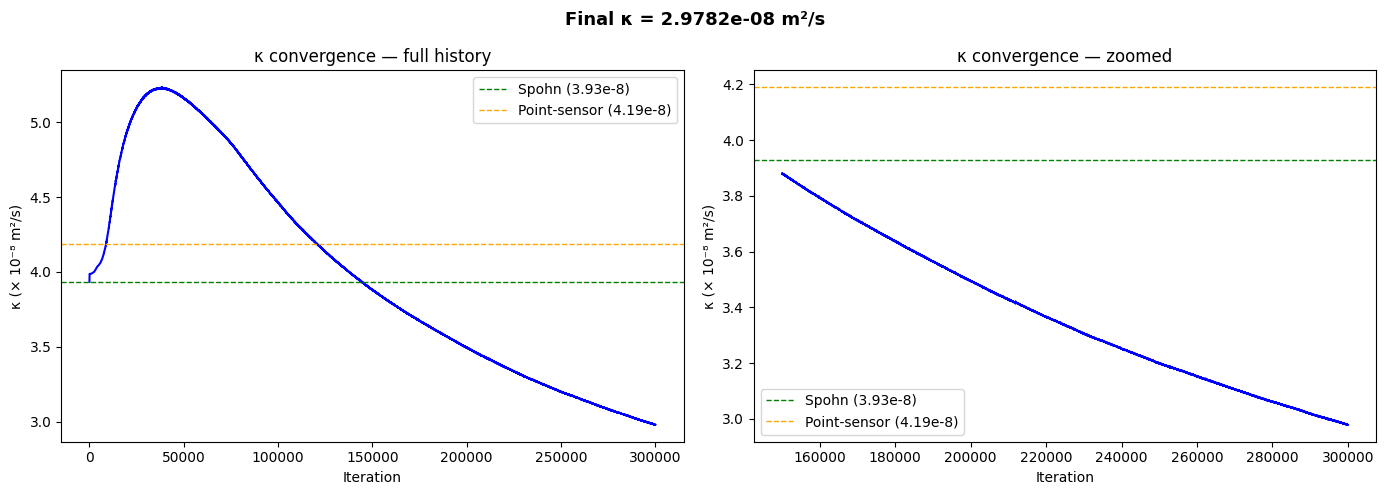

Final κ:          2.9782e-08 m²/s
Spohn reference:  3.93e-8 m²/s  (diff: -24.2%)


In [ ]:
# ── κ convergence plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

iters = jnp.arange(1, len(kappa_history) + 1)

# (a) Full history
axes[0].plot(iters, jnp.array(kappa_history) * 1e8, 'b-', lw=1.5)
axes[0].axhline(3.93, color='green', ls='--', lw=1, label='Spohn (3.93e-8)')
axes[0].axhline(4.19, color='orange', ls='--', lw=1, label='Point-sensor (4.19e-8)')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('κ (× 10⁻⁸ m²/s)')
axes[0].set_title('κ convergence — full history')
axes[0].legend()

# (b) Zoomed on last 50% to see plateau
half = len(kappa_history) // 2
axes[1].plot(iters[half:], jnp.array(kappa_history)[half:] * 1e8, 'b-', lw=1.5)
axes[1].axhline(3.93, color='green', ls='--', lw=1, label='Spohn (3.93e-8)')
axes[1].axhline(4.19, color='orange', ls='--', lw=1, label='Point-sensor (4.19e-8)')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('κ (× 10⁻⁸ m²/s)')
axes[1].set_title('κ convergence — zoomed')
axes[1].legend()

final_kappa = kappa_history[-1]
plt.suptitle(f'Final κ = {final_kappa:.4e} m²/s', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('point_sensor_graphs/kappa_convergence_ps_3.93e-8_run01.png', dpi=150)
plt.show()

print(f"Final κ:          {final_kappa:.4e} m²/s")
print(f"Spohn reference:  3.93e-8 m²/s  (diff: {(final_kappa - 3.93e-8)/3.93e-8 * 100:+.1f}%)")

In [ ]:
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import openpyxl
import optax

import jax.numpy as jnp

import copy
import pickle

# Problem parameters

depth = 0.4           # domain depth [m]
sol_seconds = 88775.244  # one sol [s]

avg_bottom_temp = 225.6  # average bottom temperature (K)
mole_depth = 0.094  # representative depth for diurnal signal [m]

# TEM-A Sol 1202 = mole temperature over one sol (the warmest sol sampled)
# RAD Sol 511   = surface temperature from radiometer (Spohn's proxy for sol 1202)

wb_diurnal = openpyxl.load_workbook(
    '../resources/data/Mars Soil Temperatures and Thermal Properties from Diurnal Wave data.xlsx',
    data_only=True
)

with open('checkpoints_point_sensor/ps_3.93e-8_run01.pkl', 'rb') as f:
    checkpoint = pickle.load(f)


kappa = checkpoint['final_kappa']


# --- Mole temperature (TEM-A Sol 1202) ---
ws_tem = wb_diurnal['TEM-A Sol 1202']
ltst_mole, temp_mole = [], []
for row in ws_tem.iter_rows(min_row=2, values_only=True):
    # Column index 6 = 'LTST Conversion step 2' (hours, 0-24)
    # Column index 7 = 'average T15, T16' (Kelvin)
    ltst_val = row[6]
    temp_val = row[7]
    if ltst_val is not None and temp_val is not None:
        try:
            t = float(ltst_val)
            T = float(temp_val)
            if 0 <= t <= 24 and 200 < T < 260:
                ltst_mole.append(t)
                temp_mole.append(T)
        except (ValueError, TypeError):
            pass


# --- Surface temperature (RAD Sol 511) ---
ws_rad = wb_diurnal['RAD SOL 511 D']
ltst_surf, temp_surf = [], []
for row in ws_rad.iter_rows(min_row=2, values_only=True):
    # Column index 4 = 'LTST converted' (hours)
    # Column index 5 = 'FOV 2 Temperature converted' (Kelvin)
    try:
        t = float(row[4])
        T = float(row[5])
        if 0 <= t <= 24 and 150 < T < 350:
            ltst_surf.append(t)
            temp_surf.append(T)
    except (ValueError, TypeError):
        pass

# Sort surface data by LTST (it may not be in order)
sorted_surf = sorted(zip(ltst_surf, temp_surf))
ltst_surf = [x[0] for x in sorted_surf]
temp_surf = [x[1] for x in sorted_surf]

# Conversion from hours to seconds for the time points. Make sure it is mapped correctly to the Mars sol time (0-88775.244 seconds)
ltst_mole = [t * sol_seconds / 24 for t in ltst_mole]
ltst_surf = [t * sol_seconds / 24 for t in ltst_surf]


# 1. Boundary Condition points (552 points each edge as we have 552 time points in the surface data)
n_surface = len(ltst_surf)  # Should be 552

# Surface boundary (x=0):
t_bc_surface = jnp.array(ltst_surf).reshape(-1, 1)  # (552, 1)
x_bc_surface = jnp.zeros((n_surface, 1))  # (552, 1)

u_bc_surface = jnp.array(temp_surf).reshape(-1, 1)  # (552, 1)

# Bottom boundary (x=depth):
t_bc_bottom = jnp.linspace(0, sol_seconds, n_surface).reshape(-1, 1)  # (552, 1)
x_bc_bottom = jnp.ones((n_surface, 1)) * depth

u_bc_bottom = jnp.ones((n_surface, 1)) * avg_bottom_temp  # (552, 1)

# Combine them:
t_bc = jnp.concatenate([t_bc_surface, t_bc_bottom])
x_bc = jnp.concatenate([x_bc_surface, x_bc_bottom])
u_bc = jnp.concatenate([u_bc_surface, u_bc_bottom])


# 2. Physics collocation points (100 * 100 = 10,000 points)
key = random.PRNGKey(0)
key1, key2 = random.split(key)
t_physics = random.uniform(key1, (10000, 1), minval=0, maxval=sol_seconds)
x_physics = random.uniform(key2, (10000, 1), minval=0, maxval=depth)


# 3. Data points for Data Loss (5550 points)
# We can use the mole temperature data as additional data points inside the domain (not just at the boundaries). This will help guide the network to learn the correct solution.

t_data = jnp.array(ltst_mole).reshape(-1, 1)
x_data = jnp.ones((len(ltst_mole), 1)) * mole_depth
u_data = jnp.array(temp_mole).reshape(-1, 1)


# Normalise the data so the network only sees values of order 1. This helps with training stability and convergence. We will need to un-normalise the predictions later to compare with the original data.

# Normalisation parameters
t_min, t_max = 0.0, sol_seconds
x_min, x_max = 0.0, depth
u_min, u_max = 185.0, 300.0  # Based on the range of temperatures in the data

def normalize_t(t): return ( t - t_min) / (t_max - t_min)
def normalize_x(x): return ( x - x_min) / (x_max - x_min)
def normalize_u(u): return ( u - u_min) / (u_max - u_min)

def unnormalize_u(u_norm): return u_norm * (u_max - u_min) + u_min

# Normalize all data
t_bc = normalize_t(t_bc)
x_bc = normalize_x(x_bc)
u_bc = normalize_u(u_bc)

t_physics = normalize_t(t_physics)
x_physics = normalize_x(x_physics)

t_data = normalize_t(t_data)
x_data = normalize_x(x_data)
u_data = normalize_u(u_data)

#Normalize kappa as well (since it appears in the physics residual)
def normalize_kappa(kappa):
    return kappa * (t_max - t_min) / ((x_max - x_min)**2)

# Neural Network

def init_network_params(layer_sizes, key):
    """
    Initialize parameters for a fully connected network.

    Args:
        layer_sizes: List of layer sizes, e.g., [2, 32, 32, 32, 1]
                    (input_dim, hidden1, hidden2, hidden3, output_dim)
        key: JAX random key for initialization

    Returns:
        params: idctionary containging the network list of dictionaries and log_kappa
    """
    # Split random key for each layer
    keys = random.split(key, len(layer_sizes))

    params = {}

    network = []
    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]

        # Split key for weights and biases
        w_key, b_key = random.split(keys[i])

        # Xavier initialization for weights
        network.append({
            'w': random.normal(w_key, (n_in, n_out)) * jnp.sqrt(2.0 / n_in),
            'b': jnp.zeros(n_out)
        })

    params['network'] = network
    params['log_kappa'] = jnp.log(kappa)  # Learn log(kappa) to ensure positivity

    return params


def network(params, x):
    """
    Forward pass through the network.

    Args:
        params: List of layer parameters (from init_network_params)
        x: Input array, shape (batch_size, input_dim)

    Returns:
        Output array, shape (batch_size, output_dim)
    """
    # Process all hidden layers (all but last)


    for layer in params['network'][:-1]:
        # Linear transformation: x @ W + b
        x = jnp.dot(x, layer['w']) + layer['b']
        # Activation function
        x = jnp.tanh(x)

    # Output layer (no activation)
    final_layer = params['network'][-1]
    x = jnp.dot(x, final_layer['w']) + final_layer['b']

    return x


# Calculate Residual

def physics_residual_single(params, t_point, x_point):

    def u(t_val, x_val):
        tx_in = jnp.array([[t_val, x_val]])
        return network(params, tx_in)[0, 0]

    du_dt = grad(u, argnums=0)(t_point, x_point)

    d2u_dx2 = grad(grad(u, argnums = 1), argnums=1)(t_point, x_point)

    kappa_eff = normalize_kappa(jnp.exp(params['log_kappa']))  # Ensure positivity

    return du_dt / kappa_eff - d2u_dx2


# Vectorize to handle all physics points at once
# So vmap will call physics_residual_single 10000 times, once for each (t, x) pair, keeping params fixed.
physics_residual_batch = vmap(physics_residual_single, in_axes=(None, 0, 0))


# Initialize network
key = random.PRNGKey(123)
layer_sizes = [2, 64, 64, 64, 64, 1]  # 2 inputs (t, x), 1 output (u)
params = checkpoint['params']

# Initialize optimizer
learning_rate = 1e-3
schedule = optax.piecewise_constant_schedule(init_value=learning_rate, boundaries_and_scales={60000: 0.1})
optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(params)


@jit
def update_step(params, opt_state,
                t_bc, x_bc, u_bc, t_physics, x_physics, t_data, x_data, u_data):

    def loss_fn(params):

        # 1. Boundary Condition Loss
        tx_bc = jnp.concatenate([t_bc, x_bc], axis=1)
        u_pred_bc = network(params, tx_bc)
        bc_loss = jnp.mean((u_pred_bc - u_bc)**2)

        # 2. Physics Loss
        physics_residuals = physics_residual_batch(params,
                                                t_physics.ravel(), # (10000,) not (10000, 1)
                                                x_physics.ravel()) # (10000,) not (10000, 1)
        physics_loss = jnp.mean(physics_residuals**2) # Physics residual is of 10000 points.

        # 3. Data Loss
        tx_data = jnp.concatenate([t_data, x_data], axis=1)
        u_pred_data = network(params, tx_data)
        data_loss = jnp.mean((u_pred_data - u_data)**2)

        return  bc_loss * 100 + physics_loss + data_loss * 50, (bc_loss, physics_loss, data_loss)

        # Compute loss and gradients
    (loss_val, individual_loss), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)

    # Update parameters
    updates, new_opt_state = optimizer.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)

    return new_params, new_opt_state, loss_val, individual_loss


# Training parameters
num_iterations = 500000
save_every = 150  # Save every 150 iterations
print_every = 1000

# Storage for snapshots
snapshots = []
snapshot_iterations = []

# Prepare physics points (flatten for vmap)
t_phys_flat = t_physics.ravel()
x_phys_flat = x_physics.ravel()

# Training loop
losses = []
losses_bc = []
losses_phys = []
losses_data = []
kappa_history = []
for i in range(num_iterations):
    params, opt_state, loss, individual_loss = update_step(
        params, opt_state,
        t_bc, x_bc, u_bc,
        t_phys_flat, x_phys_flat,
        t_data, x_data, u_data
    )

    losses.append(loss)
    losses_bc.append(individual_loss[0])
    losses_phys.append(individual_loss[1])
    losses_data.append(individual_loss[2])
    kappa_history.append(float(jnp.exp(params['log_kappa'])))


    # Save snapshot every 150 iterations
    if (i + 1) % save_every == 0:
        # Make a copy of params (important!)
        snapshots.append(copy.deepcopy(params))
        snapshot_iterations.append(i + 1)


    if (i + 1) % print_every == 0:
        print(f"Iteration {i+1}/{num_iterations}, Loss: {loss:.6f}")
        print(f"  BC Loss: {individual_loss[0]:.6f}, Physics Loss: {individual_loss[1]:.6f}, Data Loss: {individual_loss[2]:.6f}")
        print(f"  Current kappa: {jnp.exp(params['log_kappa']):.2e} m^2/s")


checkpoint = {
    # Learned parameters
    'params': jax.device_get(params),
    'opt_state': jax.device_get(opt_state),

    # Loss histories
    'losses': [float(l) for l in losses],
    'losses_bc': [float(l) for l in losses_bc],
    'losses_phys': [float(l) for l in losses_phys],
    'losses_data': [float(l) for l in losses_data],
    'kappa_history': kappa_history,

    # Snapshots for animation
    'snapshots': [jax.device_get(s) for s in snapshots],
    'snapshot_iterations': snapshot_iterations,

    # Training config (so you remember what produced this)
    'num_iterations': num_iterations,
    'layer_sizes': layer_sizes,
    'learning_rate': learning_rate,
    'final_kappa': float(jnp.exp(params['log_kappa'])),
}

with open('checkpoints_point_sensor/ps_3.93e-8_run02.pkl', 'wb') as f:
    pickle.dump(checkpoint, f)

print(f"Checkpoint saved. Final kappa: {jnp.exp(params['log_kappa']):.2e}")



/usr/local/lib/python3.12/dist-packages/openpyxl/reader/drawings.py:67: UserWarning: wmf image format is not supported so the image is being dropped
  warn(msg)


Iteration 1000/500000, Loss: 0.021075
  BC Loss: 0.000004, Physics Loss: 0.000557, Data Loss: 0.000402
  Current kappa: 2.98e-08 m^2/s
Iteration 2000/500000, Loss: 0.024760
  BC Loss: 0.000007, Physics Loss: 0.003701, Data Loss: 0.000406
  Current kappa: 2.97e-08 m^2/s
Iteration 3000/500000, Loss: 0.025652
  BC Loss: 0.000005, Physics Loss: 0.005219, Data Loss: 0.000399
  Current kappa: 2.97e-08 m^2/s
Iteration 4000/500000, Loss: 0.028503
  BC Loss: 0.000005, Physics Loss: 0.007872, Data Loss: 0.000403
  Current kappa: 2.96e-08 m^2/s
Iteration 5000/500000, Loss: 0.037417
  BC Loss: 0.000009, Physics Loss: 0.016484, Data Loss: 0.000400
  Current kappa: 2.96e-08 m^2/s
Iteration 6000/500000, Loss: 0.024809
  BC Loss: 0.000004, Physics Loss: 0.004313, Data Loss: 0.000401
  Current kappa: 2.96e-08 m^2/s
Iteration 7000/500000, Loss: 0.027912
  BC Loss: 0.000011, Physics Loss: 0.006316, Data Loss: 0.000410
  Current kappa: 2.95e-08 m^2/s
Iteration 8000/500000, Loss: 0.023178
  BC Loss: 0.0000

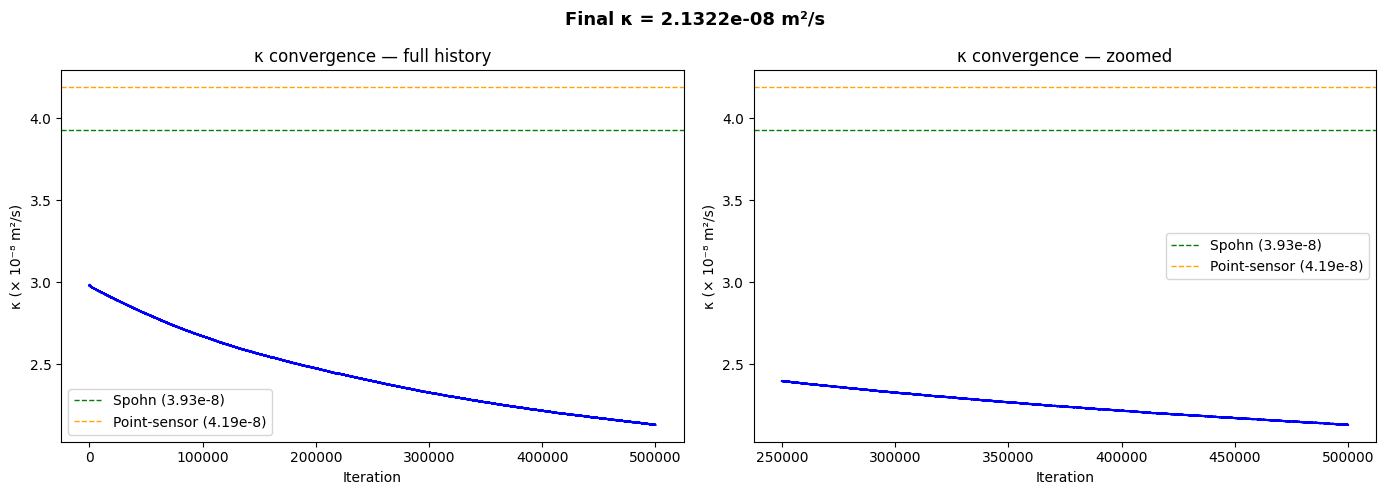

Final κ:          2.1322e-08 m²/s
Spohn reference:  3.93e-8 m²/s  (diff: -45.7%)


In [ ]:
# ── κ convergence plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

iters = jnp.arange(1, len(kappa_history) + 1)

# (a) Full history
axes[0].plot(iters, jnp.array(kappa_history) * 1e8, 'b-', lw=1.5)
axes[0].axhline(3.93, color='green', ls='--', lw=1, label='Spohn (3.93e-8)')
axes[0].axhline(4.19, color='orange', ls='--', lw=1, label='Point-sensor (4.19e-8)')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('κ (× 10⁻⁸ m²/s)')
axes[0].set_title('κ convergence — full history')
axes[0].legend()

# (b) Zoomed on last 50% to see plateau
half = len(kappa_history) // 2
axes[1].plot(iters[half:], jnp.array(kappa_history)[half:] * 1e8, 'b-', lw=1.5)
axes[1].axhline(3.93, color='green', ls='--', lw=1, label='Spohn (3.93e-8)')
axes[1].axhline(4.19, color='orange', ls='--', lw=1, label='Point-sensor (4.19e-8)')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('κ (× 10⁻⁸ m²/s)')
axes[1].set_title('κ convergence — zoomed')
axes[1].legend()

final_kappa = kappa_history[-1]
plt.suptitle(f'Final κ = {final_kappa:.4e} m²/s', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('point_sensor_graphs/kappa_convergence_ps_3.93e-8_run02.png', dpi=150)
plt.show()

print(f"Final κ:          {final_kappa:.4e} m²/s")
print(f"Spohn reference:  3.93e-8 m²/s  (diff: {(final_kappa - 3.93e-8)/3.93e-8 * 100:+.1f}%)")

In [ ]:
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import openpyxl
import optax

import jax.numpy as jnp

import copy
import pickle

# Problem parameters

depth = 0.4           # domain depth [m]
sol_seconds = 88775.244  # one sol [s]

avg_bottom_temp = 225.6  # average bottom temperature (K)
mole_depth = 0.094  # representative depth for diurnal signal [m]

# TEM-A Sol 1202 = mole temperature over one sol (the warmest sol sampled)
# RAD Sol 511   = surface temperature from radiometer (Spohn's proxy for sol 1202)

wb_diurnal = openpyxl.load_workbook(
    '../resources/data/Mars Soil Temperatures and Thermal Properties from Diurnal Wave data.xlsx',
    data_only=True
)

with open('checkpoints_point_sensor/ps_3.93e-8_run02.pkl', 'rb') as f:
    checkpoint = pickle.load(f)


kappa = checkpoint['final_kappa']


# --- Mole temperature (TEM-A Sol 1202) ---
ws_tem = wb_diurnal['TEM-A Sol 1202']
ltst_mole, temp_mole = [], []
for row in ws_tem.iter_rows(min_row=2, values_only=True):
    # Column index 6 = 'LTST Conversion step 2' (hours, 0-24)
    # Column index 7 = 'average T15, T16' (Kelvin)
    ltst_val = row[6]
    temp_val = row[7]
    if ltst_val is not None and temp_val is not None:
        try:
            t = float(ltst_val)
            T = float(temp_val)
            if 0 <= t <= 24 and 200 < T < 260:
                ltst_mole.append(t)
                temp_mole.append(T)
        except (ValueError, TypeError):
            pass


# --- Surface temperature (RAD Sol 511) ---
ws_rad = wb_diurnal['RAD SOL 511 D']
ltst_surf, temp_surf = [], []
for row in ws_rad.iter_rows(min_row=2, values_only=True):
    # Column index 4 = 'LTST converted' (hours)
    # Column index 5 = 'FOV 2 Temperature converted' (Kelvin)
    try:
        t = float(row[4])
        T = float(row[5])
        if 0 <= t <= 24 and 150 < T < 350:
            ltst_surf.append(t)
            temp_surf.append(T)
    except (ValueError, TypeError):
        pass

# Sort surface data by LTST (it may not be in order)
sorted_surf = sorted(zip(ltst_surf, temp_surf))
ltst_surf = [x[0] for x in sorted_surf]
temp_surf = [x[1] for x in sorted_surf]

# Conversion from hours to seconds for the time points. Make sure it is mapped correctly to the Mars sol time (0-88775.244 seconds)
ltst_mole = [t * sol_seconds / 24 for t in ltst_mole]
ltst_surf = [t * sol_seconds / 24 for t in ltst_surf]


# 1. Boundary Condition points (552 points each edge as we have 552 time points in the surface data)
n_surface = len(ltst_surf)  # Should be 552

# Surface boundary (x=0):
t_bc_surface = jnp.array(ltst_surf).reshape(-1, 1)  # (552, 1)
x_bc_surface = jnp.zeros((n_surface, 1))  # (552, 1)

u_bc_surface = jnp.array(temp_surf).reshape(-1, 1)  # (552, 1)

# Bottom boundary (x=depth):
t_bc_bottom = jnp.linspace(0, sol_seconds, n_surface).reshape(-1, 1)  # (552, 1)
x_bc_bottom = jnp.ones((n_surface, 1)) * depth

u_bc_bottom = jnp.ones((n_surface, 1)) * avg_bottom_temp  # (552, 1)

# Combine them:
t_bc = jnp.concatenate([t_bc_surface, t_bc_bottom])
x_bc = jnp.concatenate([x_bc_surface, x_bc_bottom])
u_bc = jnp.concatenate([u_bc_surface, u_bc_bottom])


# 2. Physics collocation points (100 * 100 = 10,000 points)
key = random.PRNGKey(0)
key1, key2 = random.split(key)
t_physics = random.uniform(key1, (10000, 1), minval=0, maxval=sol_seconds)
x_physics = random.uniform(key2, (10000, 1), minval=0, maxval=depth)


# 3. Data points for Data Loss (5550 points)
# We can use the mole temperature data as additional data points inside the domain (not just at the boundaries). This will help guide the network to learn the correct solution.

t_data = jnp.array(ltst_mole).reshape(-1, 1)
x_data = jnp.ones((len(ltst_mole), 1)) * mole_depth
u_data = jnp.array(temp_mole).reshape(-1, 1)


# Normalise the data so the network only sees values of order 1. This helps with training stability and convergence. We will need to un-normalise the predictions later to compare with the original data.

# Normalisation parameters
t_min, t_max = 0.0, sol_seconds
x_min, x_max = 0.0, depth
u_min, u_max = 185.0, 300.0  # Based on the range of temperatures in the data

def normalize_t(t): return ( t - t_min) / (t_max - t_min)
def normalize_x(x): return ( x - x_min) / (x_max - x_min)
def normalize_u(u): return ( u - u_min) / (u_max - u_min)

def unnormalize_u(u_norm): return u_norm * (u_max - u_min) + u_min

# Normalize all data
t_bc = normalize_t(t_bc)
x_bc = normalize_x(x_bc)
u_bc = normalize_u(u_bc)

t_physics = normalize_t(t_physics)
x_physics = normalize_x(x_physics)

t_data = normalize_t(t_data)
x_data = normalize_x(x_data)
u_data = normalize_u(u_data)

#Normalize kappa as well (since it appears in the physics residual)
def normalize_kappa(kappa):
    return kappa * (t_max - t_min) / ((x_max - x_min)**2)

# Neural Network

def init_network_params(layer_sizes, key):
    """
    Initialize parameters for a fully connected network.

    Args:
        layer_sizes: List of layer sizes, e.g., [2, 32, 32, 32, 1]
                    (input_dim, hidden1, hidden2, hidden3, output_dim)
        key: JAX random key for initialization

    Returns:
        params: idctionary containging the network list of dictionaries and log_kappa
    """
    # Split random key for each layer
    keys = random.split(key, len(layer_sizes))

    params = {}

    network = []
    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]

        # Split key for weights and biases
        w_key, b_key = random.split(keys[i])

        # Xavier initialization for weights
        network.append({
            'w': random.normal(w_key, (n_in, n_out)) * jnp.sqrt(2.0 / n_in),
            'b': jnp.zeros(n_out)
        })

    params['network'] = network
    params['log_kappa'] = jnp.log(kappa)  # Learn log(kappa) to ensure positivity

    return params


def network(params, x):
    """
    Forward pass through the network.

    Args:
        params: List of layer parameters (from init_network_params)
        x: Input array, shape (batch_size, input_dim)

    Returns:
        Output array, shape (batch_size, output_dim)
    """
    # Process all hidden layers (all but last)


    for layer in params['network'][:-1]:
        # Linear transformation: x @ W + b
        x = jnp.dot(x, layer['w']) + layer['b']
        # Activation function
        x = jnp.tanh(x)

    # Output layer (no activation)
    final_layer = params['network'][-1]
    x = jnp.dot(x, final_layer['w']) + final_layer['b']

    return x


# Calculate Residual

def physics_residual_single(params, t_point, x_point):

    def u(t_val, x_val):
        tx_in = jnp.array([[t_val, x_val]])
        return network(params, tx_in)[0, 0]

    du_dt = grad(u, argnums=0)(t_point, x_point)

    d2u_dx2 = grad(grad(u, argnums = 1), argnums=1)(t_point, x_point)

    kappa_eff = normalize_kappa(jnp.exp(params['log_kappa']))  # Ensure positivity

    return du_dt / kappa_eff - d2u_dx2


# Vectorize to handle all physics points at once
# So vmap will call physics_residual_single 10000 times, once for each (t, x) pair, keeping params fixed.
physics_residual_batch = vmap(physics_residual_single, in_axes=(None, 0, 0))


# Initialize network
key = random.PRNGKey(123)
layer_sizes = [2, 64, 64, 64, 64, 1]  # 2 inputs (t, x), 1 output (u)
params = checkpoint['params']

# Initialize optimizer
learning_rate = 1e-3
schedule = optax.piecewise_constant_schedule(init_value=learning_rate, boundaries_and_scales={60000: 0.1})
optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(params)


@jit
def update_step(params, opt_state,
                t_bc, x_bc, u_bc, t_physics, x_physics, t_data, x_data, u_data):

    def loss_fn(params):

        # 1. Boundary Condition Loss
        tx_bc = jnp.concatenate([t_bc, x_bc], axis=1)
        u_pred_bc = network(params, tx_bc)
        bc_loss = jnp.mean((u_pred_bc - u_bc)**2)

        # 2. Physics Loss
        physics_residuals = physics_residual_batch(params,
                                                t_physics.ravel(), # (10000,) not (10000, 1)
                                                x_physics.ravel()) # (10000,) not (10000, 1)
        physics_loss = jnp.mean(physics_residuals**2) # Physics residual is of 10000 points.

        # 3. Data Loss
        tx_data = jnp.concatenate([t_data, x_data], axis=1)
        u_pred_data = network(params, tx_data)
        data_loss = jnp.mean((u_pred_data - u_data)**2)

        return  bc_loss * 100 + physics_loss + data_loss * 50, (bc_loss, physics_loss, data_loss)

        # Compute loss and gradients
    (loss_val, individual_loss), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)

    # Update parameters
    updates, new_opt_state = optimizer.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)

    return new_params, new_opt_state, loss_val, individual_loss


# Training parameters
num_iterations = 500000
save_every = 150  # Save every 150 iterations
print_every = 1000

# Storage for snapshots
snapshots = []
snapshot_iterations = []

# Prepare physics points (flatten for vmap)
t_phys_flat = t_physics.ravel()
x_phys_flat = x_physics.ravel()

# Training loop
losses = []
losses_bc = []
losses_phys = []
losses_data = []
kappa_history = []
for i in range(num_iterations):
    params, opt_state, loss, individual_loss = update_step(
        params, opt_state,
        t_bc, x_bc, u_bc,
        t_phys_flat, x_phys_flat,
        t_data, x_data, u_data
    )

    losses.append(loss)
    losses_bc.append(individual_loss[0])
    losses_phys.append(individual_loss[1])
    losses_data.append(individual_loss[2])
    kappa_history.append(float(jnp.exp(params['log_kappa'])))


    # Save snapshot every 150 iterations
    if (i + 1) % save_every == 0:
        # Make a copy of params (important!)
        snapshots.append(copy.deepcopy(params))
        snapshot_iterations.append(i + 1)


    if (i + 1) % print_every == 0:
        print(f"Iteration {i+1}/{num_iterations}, Loss: {loss:.6f}")
        print(f"  BC Loss: {individual_loss[0]:.6f}, Physics Loss: {individual_loss[1]:.6f}, Data Loss: {individual_loss[2]:.6f}")
        print(f"  Current kappa: {jnp.exp(params['log_kappa']):.2e} m^2/s")


checkpoint = {
    # Learned parameters
    'params': jax.device_get(params),
    'opt_state': jax.device_get(opt_state),

    # Loss histories
    'losses': [float(l) for l in losses],
    'losses_bc': [float(l) for l in losses_bc],
    'losses_phys': [float(l) for l in losses_phys],
    'losses_data': [float(l) for l in losses_data],
    'kappa_history': kappa_history,

    # Snapshots for animation
    'snapshots': [jax.device_get(s) for s in snapshots],
    'snapshot_iterations': snapshot_iterations,

    # Training config (so you remember what produced this)
    'num_iterations': num_iterations,
    'layer_sizes': layer_sizes,
    'learning_rate': learning_rate,
    'final_kappa': float(jnp.exp(params['log_kappa'])),
}

with open('checkpoints_point_sensor/ps_3.93e-8_run03.pkl', 'wb') as f:
    pickle.dump(checkpoint, f)

print(f"Checkpoint saved. Final kappa: {jnp.exp(params['log_kappa']):.2e}")



/usr/local/lib/python3.12/dist-packages/openpyxl/reader/drawings.py:67: UserWarning: wmf image format is not supported so the image is being dropped
  warn(msg)


Iteration 1000/500000, Loss: 0.015939
  BC Loss: 0.000003, Physics Loss: 0.001343, Data Loss: 0.000287
  Current kappa: 2.13e-08 m^2/s
Iteration 2000/500000, Loss: 0.030745
  BC Loss: 0.000004, Physics Loss: 0.016063, Data Loss: 0.000286
  Current kappa: 2.13e-08 m^2/s
Iteration 3000/500000, Loss: 0.016365
  BC Loss: 0.000003, Physics Loss: 0.001703, Data Loss: 0.000287
  Current kappa: 2.13e-08 m^2/s
Iteration 4000/500000, Loss: 0.021224
  BC Loss: 0.000007, Physics Loss: 0.006062, Data Loss: 0.000290
  Current kappa: 2.13e-08 m^2/s
Iteration 5000/500000, Loss: 0.017246
  BC Loss: 0.000002, Physics Loss: 0.002656, Data Loss: 0.000287
  Current kappa: 2.13e-08 m^2/s
Iteration 6000/500000, Loss: 0.017669
  BC Loss: 0.000003, Physics Loss: 0.003010, Data Loss: 0.000287
  Current kappa: 2.13e-08 m^2/s
Iteration 7000/500000, Loss: 0.018045
  BC Loss: 0.000004, Physics Loss: 0.003314, Data Loss: 0.000286
  Current kappa: 2.12e-08 m^2/s
Iteration 8000/500000, Loss: 0.023956
  BC Loss: 0.0000

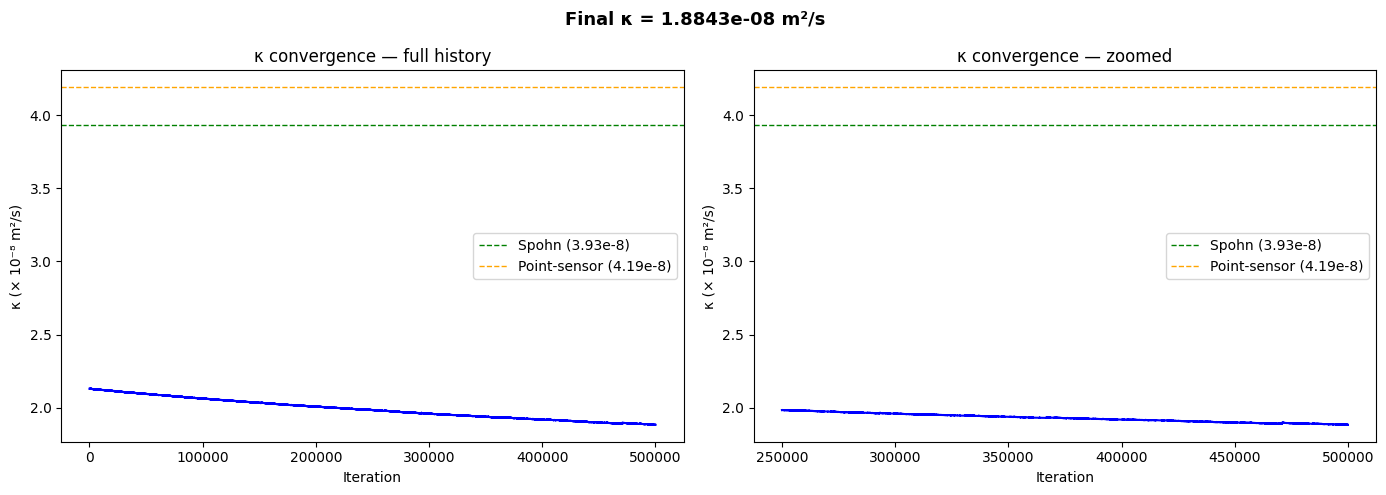

Final κ:          1.8843e-08 m²/s
Spohn reference:  3.93e-8 m²/s  (diff: -52.1%)


In [ ]:
# ── κ convergence plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

iters = jnp.arange(1, len(kappa_history) + 1)

# (a) Full history
axes[0].plot(iters, jnp.array(kappa_history) * 1e8, 'b-', lw=1.5)
axes[0].axhline(3.93, color='green', ls='--', lw=1, label='Spohn (3.93e-8)')
axes[0].axhline(4.19, color='orange', ls='--', lw=1, label='Point-sensor (4.19e-8)')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('κ (× 10⁻⁸ m²/s)')
axes[0].set_title('κ convergence — full history')
axes[0].legend()

# (b) Zoomed on last 50% to see plateau
half = len(kappa_history) // 2
axes[1].plot(iters[half:], jnp.array(kappa_history)[half:] * 1e8, 'b-', lw=1.5)
axes[1].axhline(3.93, color='green', ls='--', lw=1, label='Spohn (3.93e-8)')
axes[1].axhline(4.19, color='orange', ls='--', lw=1, label='Point-sensor (4.19e-8)')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('κ (× 10⁻⁸ m²/s)')
axes[1].set_title('κ convergence — zoomed')
axes[1].legend()

final_kappa = kappa_history[-1]
plt.suptitle(f'Final κ = {final_kappa:.4e} m²/s', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('point_sensor_graphs/kappa_convergence_ps_3.93e-8_run03.png', dpi=150)
plt.show()

print(f"Final κ:          {final_kappa:.4e} m²/s")
print(f"Spohn reference:  3.93e-8 m²/s  (diff: {(final_kappa - 3.93e-8)/3.93e-8 * 100:+.1f}%)")

In [ ]:
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import openpyxl
import optax

import jax.numpy as jnp

import copy
import pickle

# Problem parameters

depth = 0.4           # domain depth [m]
sol_seconds = 88775.244  # one sol [s]

avg_bottom_temp = 225.6  # average bottom temperature (K)
mole_depth = 0.094  # representative depth for diurnal signal [m]

# TEM-A Sol 1202 = mole temperature over one sol (the warmest sol sampled)
# RAD Sol 511   = surface temperature from radiometer (Spohn's proxy for sol 1202)

wb_diurnal = openpyxl.load_workbook(
    '../resources/data/Mars Soil Temperatures and Thermal Properties from Diurnal Wave data.xlsx',
    data_only=True
)

with open('checkpoints_point_sensor/ps_3.93e-8_run03.pkl', 'rb') as f:
    checkpoint = pickle.load(f)


kappa = checkpoint['final_kappa']


# --- Mole temperature (TEM-A Sol 1202) ---
ws_tem = wb_diurnal['TEM-A Sol 1202']
ltst_mole, temp_mole = [], []
for row in ws_tem.iter_rows(min_row=2, values_only=True):
    # Column index 6 = 'LTST Conversion step 2' (hours, 0-24)
    # Column index 7 = 'average T15, T16' (Kelvin)
    ltst_val = row[6]
    temp_val = row[7]
    if ltst_val is not None and temp_val is not None:
        try:
            t = float(ltst_val)
            T = float(temp_val)
            if 0 <= t <= 24 and 200 < T < 260:
                ltst_mole.append(t)
                temp_mole.append(T)
        except (ValueError, TypeError):
            pass


# --- Surface temperature (RAD Sol 511) ---
ws_rad = wb_diurnal['RAD SOL 511 D']
ltst_surf, temp_surf = [], []
for row in ws_rad.iter_rows(min_row=2, values_only=True):
    # Column index 4 = 'LTST converted' (hours)
    # Column index 5 = 'FOV 2 Temperature converted' (Kelvin)
    try:
        t = float(row[4])
        T = float(row[5])
        if 0 <= t <= 24 and 150 < T < 350:
            ltst_surf.append(t)
            temp_surf.append(T)
    except (ValueError, TypeError):
        pass

# Sort surface data by LTST (it may not be in order)
sorted_surf = sorted(zip(ltst_surf, temp_surf))
ltst_surf = [x[0] for x in sorted_surf]
temp_surf = [x[1] for x in sorted_surf]

# Conversion from hours to seconds for the time points. Make sure it is mapped correctly to the Mars sol time (0-88775.244 seconds)
ltst_mole = [t * sol_seconds / 24 for t in ltst_mole]
ltst_surf = [t * sol_seconds / 24 for t in ltst_surf]


# 1. Boundary Condition points (552 points each edge as we have 552 time points in the surface data)
n_surface = len(ltst_surf)  # Should be 552

# Surface boundary (x=0):
t_bc_surface = jnp.array(ltst_surf).reshape(-1, 1)  # (552, 1)
x_bc_surface = jnp.zeros((n_surface, 1))  # (552, 1)

u_bc_surface = jnp.array(temp_surf).reshape(-1, 1)  # (552, 1)

# Bottom boundary (x=depth):
t_bc_bottom = jnp.linspace(0, sol_seconds, n_surface).reshape(-1, 1)  # (552, 1)
x_bc_bottom = jnp.ones((n_surface, 1)) * depth

u_bc_bottom = jnp.ones((n_surface, 1)) * avg_bottom_temp  # (552, 1)

# Combine them:
t_bc = jnp.concatenate([t_bc_surface, t_bc_bottom])
x_bc = jnp.concatenate([x_bc_surface, x_bc_bottom])
u_bc = jnp.concatenate([u_bc_surface, u_bc_bottom])


# 2. Physics collocation points (100 * 100 = 10,000 points)
key = random.PRNGKey(0)
key1, key2 = random.split(key)
t_physics = random.uniform(key1, (10000, 1), minval=0, maxval=sol_seconds)
x_physics = random.uniform(key2, (10000, 1), minval=0, maxval=depth)


# 3. Data points for Data Loss (5550 points)
# We can use the mole temperature data as additional data points inside the domain (not just at the boundaries). This will help guide the network to learn the correct solution.

t_data = jnp.array(ltst_mole).reshape(-1, 1)
x_data = jnp.ones((len(ltst_mole), 1)) * mole_depth
u_data = jnp.array(temp_mole).reshape(-1, 1)


# Normalise the data so the network only sees values of order 1. This helps with training stability and convergence. We will need to un-normalise the predictions later to compare with the original data.

# Normalisation parameters
t_min, t_max = 0.0, sol_seconds
x_min, x_max = 0.0, depth
u_min, u_max = 185.0, 300.0  # Based on the range of temperatures in the data

def normalize_t(t): return ( t - t_min) / (t_max - t_min)
def normalize_x(x): return ( x - x_min) / (x_max - x_min)
def normalize_u(u): return ( u - u_min) / (u_max - u_min)

def unnormalize_u(u_norm): return u_norm * (u_max - u_min) + u_min

# Normalize all data
t_bc = normalize_t(t_bc)
x_bc = normalize_x(x_bc)
u_bc = normalize_u(u_bc)

t_physics = normalize_t(t_physics)
x_physics = normalize_x(x_physics)

t_data = normalize_t(t_data)
x_data = normalize_x(x_data)
u_data = normalize_u(u_data)

#Normalize kappa as well (since it appears in the physics residual)
def normalize_kappa(kappa):
    return kappa * (t_max - t_min) / ((x_max - x_min)**2)

# Neural Network

def init_network_params(layer_sizes, key):
    """
    Initialize parameters for a fully connected network.

    Args:
        layer_sizes: List of layer sizes, e.g., [2, 32, 32, 32, 1]
                    (input_dim, hidden1, hidden2, hidden3, output_dim)
        key: JAX random key for initialization

    Returns:
        params: idctionary containging the network list of dictionaries and log_kappa
    """
    # Split random key for each layer
    keys = random.split(key, len(layer_sizes))

    params = {}

    network = []
    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]

        # Split key for weights and biases
        w_key, b_key = random.split(keys[i])

        # Xavier initialization for weights
        network.append({
            'w': random.normal(w_key, (n_in, n_out)) * jnp.sqrt(2.0 / n_in),
            'b': jnp.zeros(n_out)
        })

    params['network'] = network
    params['log_kappa'] = jnp.log(kappa)  # Learn log(kappa) to ensure positivity

    return params


def network(params, x):
    """
    Forward pass through the network.

    Args:
        params: List of layer parameters (from init_network_params)
        x: Input array, shape (batch_size, input_dim)

    Returns:
        Output array, shape (batch_size, output_dim)
    """
    # Process all hidden layers (all but last)


    for layer in params['network'][:-1]:
        # Linear transformation: x @ W + b
        x = jnp.dot(x, layer['w']) + layer['b']
        # Activation function
        x = jnp.tanh(x)

    # Output layer (no activation)
    final_layer = params['network'][-1]
    x = jnp.dot(x, final_layer['w']) + final_layer['b']

    return x


# Calculate Residual

def physics_residual_single(params, t_point, x_point):

    def u(t_val, x_val):
        tx_in = jnp.array([[t_val, x_val]])
        return network(params, tx_in)[0, 0]

    du_dt = grad(u, argnums=0)(t_point, x_point)

    d2u_dx2 = grad(grad(u, argnums = 1), argnums=1)(t_point, x_point)

    kappa_eff = normalize_kappa(jnp.exp(params['log_kappa']))  # Ensure positivity

    return du_dt / kappa_eff - d2u_dx2


# Vectorize to handle all physics points at once
# So vmap will call physics_residual_single 10000 times, once for each (t, x) pair, keeping params fixed.
physics_residual_batch = vmap(physics_residual_single, in_axes=(None, 0, 0))


# Initialize network
key = random.PRNGKey(123)
layer_sizes = [2, 64, 64, 64, 64, 1]  # 2 inputs (t, x), 1 output (u)
params = checkpoint['params']

# Initialize optimizer
learning_rate = 1e-3
schedule = optax.piecewise_constant_schedule(init_value=learning_rate, boundaries_and_scales={60000: 0.1})
optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(params)


@jit
def update_step(params, opt_state,
                t_bc, x_bc, u_bc, t_physics, x_physics, t_data, x_data, u_data):

    def loss_fn(params):

        # 1. Boundary Condition Loss
        tx_bc = jnp.concatenate([t_bc, x_bc], axis=1)
        u_pred_bc = network(params, tx_bc)
        bc_loss = jnp.mean((u_pred_bc - u_bc)**2)

        # 2. Physics Loss
        physics_residuals = physics_residual_batch(params,
                                                t_physics.ravel(), # (10000,) not (10000, 1)
                                                x_physics.ravel()) # (10000,) not (10000, 1)
        physics_loss = jnp.mean(physics_residuals**2) # Physics residual is of 10000 points.

        # 3. Data Loss
        tx_data = jnp.concatenate([t_data, x_data], axis=1)
        u_pred_data = network(params, tx_data)
        data_loss = jnp.mean((u_pred_data - u_data)**2)

        return  bc_loss * 100 + physics_loss + data_loss * 50, (bc_loss, physics_loss, data_loss)

        # Compute loss and gradients
    (loss_val, individual_loss), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)

    # Update parameters
    updates, new_opt_state = optimizer.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)

    return new_params, new_opt_state, loss_val, individual_loss


# Training parameters
num_iterations = 300000
save_every = 150  # Save every 150 iterations
print_every = 1000

# Storage for snapshots
snapshots = []
snapshot_iterations = []

# Prepare physics points (flatten for vmap)
t_phys_flat = t_physics.ravel()
x_phys_flat = x_physics.ravel()

# Training loop
losses = []
losses_bc = []
losses_phys = []
losses_data = []
kappa_history = []
for i in range(num_iterations):
    params, opt_state, loss, individual_loss = update_step(
        params, opt_state,
        t_bc, x_bc, u_bc,
        t_phys_flat, x_phys_flat,
        t_data, x_data, u_data
    )

    losses.append(loss)
    losses_bc.append(individual_loss[0])
    losses_phys.append(individual_loss[1])
    losses_data.append(individual_loss[2])
    kappa_history.append(float(jnp.exp(params['log_kappa'])))


    # Save snapshot every 150 iterations
    if (i + 1) % save_every == 0:
        # Make a copy of params (important!)
        snapshots.append(copy.deepcopy(params))
        snapshot_iterations.append(i + 1)


    if (i + 1) % print_every == 0:
        print(f"Iteration {i+1}/{num_iterations}, Loss: {loss:.6f}")
        print(f"  BC Loss: {individual_loss[0]:.6f}, Physics Loss: {individual_loss[1]:.6f}, Data Loss: {individual_loss[2]:.6f}")
        print(f"  Current kappa: {jnp.exp(params['log_kappa']):.2e} m^2/s")


checkpoint = {
    # Learned parameters
    'params': jax.device_get(params),
    'opt_state': jax.device_get(opt_state),

    # Loss histories
    'losses': [float(l) for l in losses],
    'losses_bc': [float(l) for l in losses_bc],
    'losses_phys': [float(l) for l in losses_phys],
    'losses_data': [float(l) for l in losses_data],
    'kappa_history': kappa_history,

    # Snapshots for animation
    'snapshots': [jax.device_get(s) for s in snapshots],
    'snapshot_iterations': snapshot_iterations,

    # Training config (so you remember what produced this)
    'num_iterations': num_iterations,
    'layer_sizes': layer_sizes,
    'learning_rate': learning_rate,
    'final_kappa': float(jnp.exp(params['log_kappa'])),
}

with open('checkpoints_point_sensor/ps_3.93e-8_run04.pkl', 'wb') as f:
    pickle.dump(checkpoint, f)

print(f"Checkpoint saved. Final kappa: {jnp.exp(params['log_kappa']):.2e}")



Iteration 1000/300000, Loss: 0.014626
  BC Loss: 0.000002, Physics Loss: 0.002386, Data Loss: 0.000241
  Current kappa: 1.88e-08 m^2/s
Iteration 2000/300000, Loss: 0.018696
  BC Loss: 0.000002, Physics Loss: 0.006415, Data Loss: 0.000241
  Current kappa: 1.88e-08 m^2/s
Iteration 3000/300000, Loss: 0.015731
  BC Loss: 0.000011, Physics Loss: 0.002158, Data Loss: 0.000250
  Current kappa: 1.88e-08 m^2/s
Iteration 4000/300000, Loss: 0.016019
  BC Loss: 0.000003, Physics Loss: 0.003708, Data Loss: 0.000241
  Current kappa: 1.88e-08 m^2/s
Iteration 5000/300000, Loss: 0.015487
  BC Loss: 0.000002, Physics Loss: 0.003242, Data Loss: 0.000241
  Current kappa: 1.88e-08 m^2/s
Iteration 6000/300000, Loss: 0.017138
  BC Loss: 0.000002, Physics Loss: 0.004803, Data Loss: 0.000242
  Current kappa: 1.88e-08 m^2/s
Iteration 7000/300000, Loss: 0.014681
  BC Loss: 0.000005, Physics Loss: 0.002024, Data Loss: 0.000244
  Current kappa: 1.88e-08 m^2/s
Iteration 8000/300000, Loss: 0.016502
  BC Loss: 0.0000

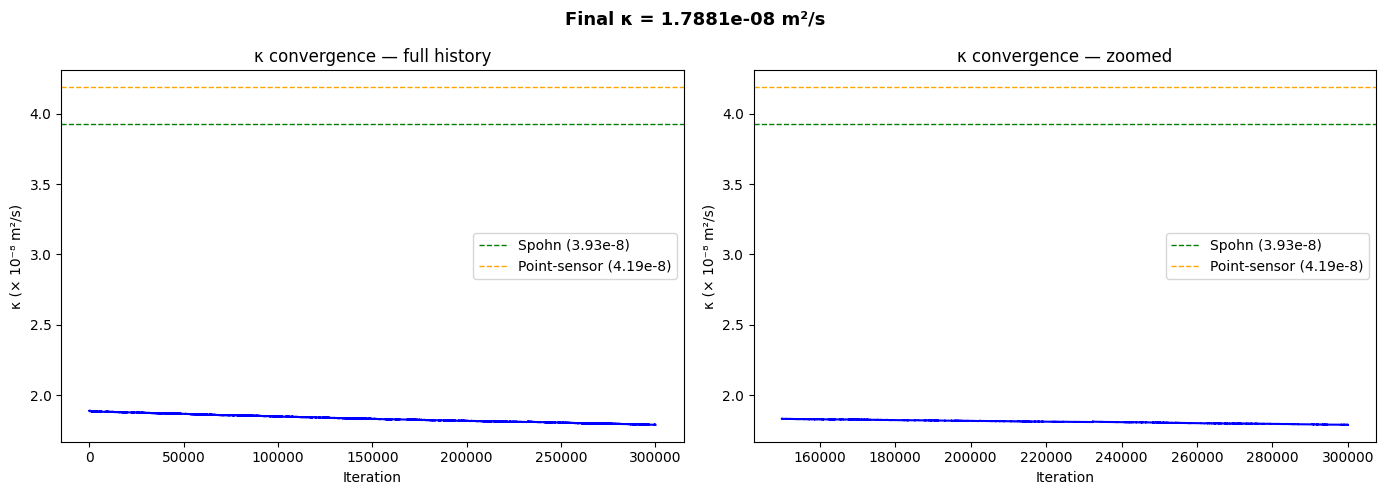

Final κ:          1.7881e-08 m²/s
Spohn reference:  3.93e-8 m²/s  (diff: -54.5%)


In [ ]:
# ── κ convergence plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

iters = jnp.arange(1, len(kappa_history) + 1)

# (a) Full history
axes[0].plot(iters, jnp.array(kappa_history) * 1e8, 'b-', lw=1.5)
axes[0].axhline(3.93, color='green', ls='--', lw=1, label='Spohn (3.93e-8)')
axes[0].axhline(4.19, color='orange', ls='--', lw=1, label='Point-sensor (4.19e-8)')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('κ (× 10⁻⁸ m²/s)')
axes[0].set_title('κ convergence — full history')
axes[0].legend()

# (b) Zoomed on last 50% to see plateau
half = len(kappa_history) // 2
axes[1].plot(iters[half:], jnp.array(kappa_history)[half:] * 1e8, 'b-', lw=1.5)
axes[1].axhline(3.93, color='green', ls='--', lw=1, label='Spohn (3.93e-8)')
axes[1].axhline(4.19, color='orange', ls='--', lw=1, label='Point-sensor (4.19e-8)')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('κ (× 10⁻⁸ m²/s)')
axes[1].set_title('κ convergence — zoomed')
axes[1].legend()

final_kappa = kappa_history[-1]
plt.suptitle(f'Final κ = {final_kappa:.4e} m²/s', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('point_sensor_graphs/kappa_convergence_ps_3.93e-8_run04.png', dpi=150)
plt.show()

print(f"Final κ:          {final_kappa:.4e} m²/s")
print(f"Spohn reference:  3.93e-8 m²/s  (diff: {(final_kappa - 3.93e-8)/3.93e-8 * 100:+.1f}%)")

In [ ]:
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import openpyxl
import optax

import jax.numpy as jnp

import copy
import pickle

# Problem parameters

depth = 0.4           # domain depth [m]
sol_seconds = 88775.244  # one sol [s]

avg_bottom_temp = 225.6  # average bottom temperature (K)
mole_depth = 0.094  # representative depth for diurnal signal [m]

# TEM-A Sol 1202 = mole temperature over one sol (the warmest sol sampled)
# RAD Sol 511   = surface temperature from radiometer (Spohn's proxy for sol 1202)

wb_diurnal = openpyxl.load_workbook(
    '../resources/data/Mars Soil Temperatures and Thermal Properties from Diurnal Wave data.xlsx',
    data_only=True
)

with open('checkpoints_point_sensor/ps_3.93e-8_run04.pkl', 'rb') as f:
    checkpoint = pickle.load(f)


kappa = checkpoint['final_kappa']


# --- Mole temperature (TEM-A Sol 1202) ---
ws_tem = wb_diurnal['TEM-A Sol 1202']
ltst_mole, temp_mole = [], []
for row in ws_tem.iter_rows(min_row=2, values_only=True):
    # Column index 6 = 'LTST Conversion step 2' (hours, 0-24)
    # Column index 7 = 'average T15, T16' (Kelvin)
    ltst_val = row[6]
    temp_val = row[7]
    if ltst_val is not None and temp_val is not None:
        try:
            t = float(ltst_val)
            T = float(temp_val)
            if 0 <= t <= 24 and 200 < T < 260:
                ltst_mole.append(t)
                temp_mole.append(T)
        except (ValueError, TypeError):
            pass


# --- Surface temperature (RAD Sol 511) ---
ws_rad = wb_diurnal['RAD SOL 511 D']
ltst_surf, temp_surf = [], []
for row in ws_rad.iter_rows(min_row=2, values_only=True):
    # Column index 4 = 'LTST converted' (hours)
    # Column index 5 = 'FOV 2 Temperature converted' (Kelvin)
    try:
        t = float(row[4])
        T = float(row[5])
        if 0 <= t <= 24 and 150 < T < 350:
            ltst_surf.append(t)
            temp_surf.append(T)
    except (ValueError, TypeError):
        pass

# Sort surface data by LTST (it may not be in order)
sorted_surf = sorted(zip(ltst_surf, temp_surf))
ltst_surf = [x[0] for x in sorted_surf]
temp_surf = [x[1] for x in sorted_surf]

# Conversion from hours to seconds for the time points. Make sure it is mapped correctly to the Mars sol time (0-88775.244 seconds)
ltst_mole = [t * sol_seconds / 24 for t in ltst_mole]
ltst_surf = [t * sol_seconds / 24 for t in ltst_surf]


# 1. Boundary Condition points (552 points each edge as we have 552 time points in the surface data)
n_surface = len(ltst_surf)  # Should be 552

# Surface boundary (x=0):
t_bc_surface = jnp.array(ltst_surf).reshape(-1, 1)  # (552, 1)
x_bc_surface = jnp.zeros((n_surface, 1))  # (552, 1)

u_bc_surface = jnp.array(temp_surf).reshape(-1, 1)  # (552, 1)

# Bottom boundary (x=depth):
t_bc_bottom = jnp.linspace(0, sol_seconds, n_surface).reshape(-1, 1)  # (552, 1)
x_bc_bottom = jnp.ones((n_surface, 1)) * depth

u_bc_bottom = jnp.ones((n_surface, 1)) * avg_bottom_temp  # (552, 1)

# Combine them:
t_bc = jnp.concatenate([t_bc_surface, t_bc_bottom])
x_bc = jnp.concatenate([x_bc_surface, x_bc_bottom])
u_bc = jnp.concatenate([u_bc_surface, u_bc_bottom])


# 2. Physics collocation points (100 * 100 = 10,000 points)
key = random.PRNGKey(0)
key1, key2 = random.split(key)
t_physics = random.uniform(key1, (10000, 1), minval=0, maxval=sol_seconds)
x_physics = random.uniform(key2, (10000, 1), minval=0, maxval=depth)


# 3. Data points for Data Loss (5550 points)
# We can use the mole temperature data as additional data points inside the domain (not just at the boundaries). This will help guide the network to learn the correct solution.

t_data = jnp.array(ltst_mole).reshape(-1, 1)
x_data = jnp.ones((len(ltst_mole), 1)) * mole_depth
u_data = jnp.array(temp_mole).reshape(-1, 1)


# Normalise the data so the network only sees values of order 1. This helps with training stability and convergence. We will need to un-normalise the predictions later to compare with the original data.

# Normalisation parameters
t_min, t_max = 0.0, sol_seconds
x_min, x_max = 0.0, depth
u_min, u_max = 185.0, 300.0  # Based on the range of temperatures in the data

def normalize_t(t): return ( t - t_min) / (t_max - t_min)
def normalize_x(x): return ( x - x_min) / (x_max - x_min)
def normalize_u(u): return ( u - u_min) / (u_max - u_min)

def unnormalize_u(u_norm): return u_norm * (u_max - u_min) + u_min

# Normalize all data
t_bc = normalize_t(t_bc)
x_bc = normalize_x(x_bc)
u_bc = normalize_u(u_bc)

t_physics = normalize_t(t_physics)
x_physics = normalize_x(x_physics)

t_data = normalize_t(t_data)
x_data = normalize_x(x_data)
u_data = normalize_u(u_data)

#Normalize kappa as well (since it appears in the physics residual)
def normalize_kappa(kappa):
    return kappa * (t_max - t_min) / ((x_max - x_min)**2)

# Neural Network

def init_network_params(layer_sizes, key):
    """
    Initialize parameters for a fully connected network.

    Args:
        layer_sizes: List of layer sizes, e.g., [2, 32, 32, 32, 1]
                    (input_dim, hidden1, hidden2, hidden3, output_dim)
        key: JAX random key for initialization

    Returns:
        params: idctionary containging the network list of dictionaries and log_kappa
    """
    # Split random key for each layer
    keys = random.split(key, len(layer_sizes))

    params = {}

    network = []
    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]

        # Split key for weights and biases
        w_key, b_key = random.split(keys[i])

        # Xavier initialization for weights
        network.append({
            'w': random.normal(w_key, (n_in, n_out)) * jnp.sqrt(2.0 / n_in),
            'b': jnp.zeros(n_out)
        })

    params['network'] = network
    params['log_kappa'] = jnp.log(kappa)  # Learn log(kappa) to ensure positivity

    return params


def network(params, x):
    """
    Forward pass through the network.

    Args:
        params: List of layer parameters (from init_network_params)
        x: Input array, shape (batch_size, input_dim)

    Returns:
        Output array, shape (batch_size, output_dim)
    """
    # Process all hidden layers (all but last)


    for layer in params['network'][:-1]:
        # Linear transformation: x @ W + b
        x = jnp.dot(x, layer['w']) + layer['b']
        # Activation function
        x = jnp.tanh(x)

    # Output layer (no activation)
    final_layer = params['network'][-1]
    x = jnp.dot(x, final_layer['w']) + final_layer['b']

    return x


# Calculate Residual

def physics_residual_single(params, t_point, x_point):

    def u(t_val, x_val):
        tx_in = jnp.array([[t_val, x_val]])
        return network(params, tx_in)[0, 0]

    du_dt = grad(u, argnums=0)(t_point, x_point)

    d2u_dx2 = grad(grad(u, argnums = 1), argnums=1)(t_point, x_point)

    kappa_eff = normalize_kappa(jnp.exp(params['log_kappa']))  # Ensure positivity

    return du_dt / kappa_eff - d2u_dx2


# Vectorize to handle all physics points at once
# So vmap will call physics_residual_single 10000 times, once for each (t, x) pair, keeping params fixed.
physics_residual_batch = vmap(physics_residual_single, in_axes=(None, 0, 0))


# Initialize network
key = random.PRNGKey(123)
layer_sizes = [2, 64, 64, 64, 64, 1]  # 2 inputs (t, x), 1 output (u)
params = checkpoint['params']

# Initialize optimizer
learning_rate = 1e-3
schedule = optax.piecewise_constant_schedule(init_value=learning_rate, boundaries_and_scales={60000: 0.1})
optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(params)


@jit
def update_step(params, opt_state,
                t_bc, x_bc, u_bc, t_physics, x_physics, t_data, x_data, u_data):

    def loss_fn(params):

        # 1. Boundary Condition Loss
        tx_bc = jnp.concatenate([t_bc, x_bc], axis=1)
        u_pred_bc = network(params, tx_bc)
        bc_loss = jnp.mean((u_pred_bc - u_bc)**2)

        # 2. Physics Loss
        physics_residuals = physics_residual_batch(params,
                                                t_physics.ravel(), # (10000,) not (10000, 1)
                                                x_physics.ravel()) # (10000,) not (10000, 1)
        physics_loss = jnp.mean(physics_residuals**2) # Physics residual is of 10000 points.

        # 3. Data Loss
        tx_data = jnp.concatenate([t_data, x_data], axis=1)
        u_pred_data = network(params, tx_data)
        data_loss = jnp.mean((u_pred_data - u_data)**2)

        return  bc_loss * 100 + physics_loss + data_loss * 50, (bc_loss, physics_loss, data_loss)

        # Compute loss and gradients
    (loss_val, individual_loss), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)

    # Update parameters
    updates, new_opt_state = optimizer.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)

    return new_params, new_opt_state, loss_val, individual_loss


# Training parameters
num_iterations = 300000
save_every = 150  # Save every 150 iterations
print_every = 1000

# Storage for snapshots
snapshots = []
snapshot_iterations = []

# Prepare physics points (flatten for vmap)
t_phys_flat = t_physics.ravel()
x_phys_flat = x_physics.ravel()

# Training loop
losses = []
losses_bc = []
losses_phys = []
losses_data = []
kappa_history = []
for i in range(num_iterations):
    params, opt_state, loss, individual_loss = update_step(
        params, opt_state,
        t_bc, x_bc, u_bc,
        t_phys_flat, x_phys_flat,
        t_data, x_data, u_data
    )

    losses.append(loss)
    losses_bc.append(individual_loss[0])
    losses_phys.append(individual_loss[1])
    losses_data.append(individual_loss[2])
    kappa_history.append(float(jnp.exp(params['log_kappa'])))


    # Save snapshot every 150 iterations
    if (i + 1) % save_every == 0:
        # Make a copy of params (important!)
        snapshots.append(copy.deepcopy(params))
        snapshot_iterations.append(i + 1)


    if (i + 1) % print_every == 0:
        print(f"Iteration {i+1}/{num_iterations}, Loss: {loss:.6f}")
        print(f"  BC Loss: {individual_loss[0]:.6f}, Physics Loss: {individual_loss[1]:.6f}, Data Loss: {individual_loss[2]:.6f}")
        print(f"  Current kappa: {jnp.exp(params['log_kappa']):.2e} m^2/s")


checkpoint = {
    # Learned parameters
    'params': jax.device_get(params),
    'opt_state': jax.device_get(opt_state),

    # Loss histories
    'losses': [float(l) for l in losses],
    'losses_bc': [float(l) for l in losses_bc],
    'losses_phys': [float(l) for l in losses_phys],
    'losses_data': [float(l) for l in losses_data],
    'kappa_history': kappa_history,

    # Snapshots for animation
    'snapshots': [jax.device_get(s) for s in snapshots],
    'snapshot_iterations': snapshot_iterations,

    # Training config (so you remember what produced this)
    'num_iterations': num_iterations,
    'layer_sizes': layer_sizes,
    'learning_rate': learning_rate,
    'final_kappa': float(jnp.exp(params['log_kappa'])),
}

with open('checkpoints_point_sensor/ps_3.93e-8_run05.pkl', 'wb') as f:
    pickle.dump(checkpoint, f)

print(f"Checkpoint saved. Final kappa: {jnp.exp(params['log_kappa']):.2e}")



Iteration 1000/300000, Loss: 0.017005
  BC Loss: 0.000002, Physics Loss: 0.005475, Data Loss: 0.000227
  Current kappa: 1.79e-08 m^2/s
Iteration 2000/300000, Loss: 0.016127
  BC Loss: 0.000003, Physics Loss: 0.004386, Data Loss: 0.000228
  Current kappa: 1.79e-08 m^2/s
Iteration 3000/300000, Loss: 0.020749
  BC Loss: 0.000005, Physics Loss: 0.008627, Data Loss: 0.000232
  Current kappa: 1.79e-08 m^2/s
Iteration 4000/300000, Loss: 0.017345
  BC Loss: 0.000002, Physics Loss: 0.005884, Data Loss: 0.000226
  Current kappa: 1.79e-08 m^2/s
Iteration 5000/300000, Loss: 0.018006
  BC Loss: 0.000002, Physics Loss: 0.006467, Data Loss: 0.000227
  Current kappa: 1.79e-08 m^2/s
Iteration 6000/300000, Loss: 0.019019
  BC Loss: 0.000004, Physics Loss: 0.007279, Data Loss: 0.000227
  Current kappa: 1.79e-08 m^2/s
Iteration 7000/300000, Loss: 0.015767
  BC Loss: 0.000002, Physics Loss: 0.004203, Data Loss: 0.000227
  Current kappa: 1.79e-08 m^2/s
Iteration 8000/300000, Loss: 0.017549
  BC Loss: 0.0000

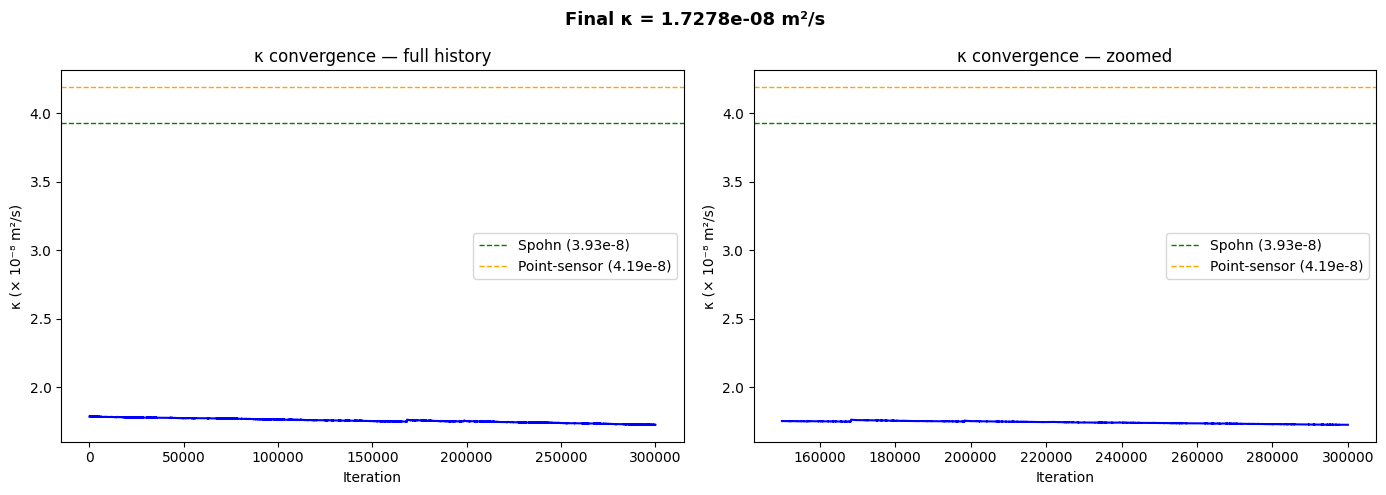

Final κ:          1.7278e-08 m²/s
Spohn reference:  3.93e-8 m²/s  (diff: -56.0%)


In [ ]:
# ── κ convergence plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

iters = jnp.arange(1, len(kappa_history) + 1)

# (a) Full history
axes[0].plot(iters, jnp.array(kappa_history) * 1e8, 'b-', lw=1.5)
axes[0].axhline(3.93, color='green', ls='--', lw=1, label='Spohn (3.93e-8)')
axes[0].axhline(4.19, color='orange', ls='--', lw=1, label='Point-sensor (4.19e-8)')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('κ (× 10⁻⁸ m²/s)')
axes[0].set_title('κ convergence — full history')
axes[0].legend()

# (b) Zoomed on last 50% to see plateau
half = len(kappa_history) // 2
axes[1].plot(iters[half:], jnp.array(kappa_history)[half:] * 1e8, 'b-', lw=1.5)
axes[1].axhline(3.93, color='green', ls='--', lw=1, label='Spohn (3.93e-8)')
axes[1].axhline(4.19, color='orange', ls='--', lw=1, label='Point-sensor (4.19e-8)')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('κ (× 10⁻⁸ m²/s)')
axes[1].set_title('κ convergence — zoomed')
axes[1].legend()

final_kappa = kappa_history[-1]
plt.suptitle(f'Final κ = {final_kappa:.4e} m²/s', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('point_sensor_graphs/kappa_convergence_ps_3.93e-8_run05.png', dpi=150)
plt.show()

print(f"Final κ:          {final_kappa:.4e} m²/s")
print(f"Spohn reference:  3.93e-8 m²/s  (diff: {(final_kappa - 3.93e-8)/3.93e-8 * 100:+.1f}%)")

# **Verify 1e-8**

In [ ]:
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import openpyxl
import optax

import jax.numpy as jnp

import copy
import pickle

# Problem parameters
kappa = 1e-8      # thermal diffusivity [m^2/s]. Intial guess for the inverse problem (Spohn's value). We will learn this parameter.
depth = 0.4           # domain depth [m]
sol_seconds = 88775.244  # one sol [s]

avg_bottom_temp = 225.6  # average bottom temperature (K)
mole_depth = 0.094  # representative depth for diurnal signal [m]

# TEM-A Sol 1202 = mole temperature over one sol (the warmest sol sampled)
# RAD Sol 511   = surface temperature from radiometer (Spohn's proxy for sol 1202)

wb_diurnal = openpyxl.load_workbook(
    '../resources/data/Mars Soil Temperatures and Thermal Properties from Diurnal Wave data.xlsx',
    data_only=True
)

# --- Mole temperature (TEM-A Sol 1202) ---
ws_tem = wb_diurnal['TEM-A Sol 1202']
ltst_mole, temp_mole = [], []
for row in ws_tem.iter_rows(min_row=2, values_only=True):
    # Column index 6 = 'LTST Conversion step 2' (hours, 0-24)
    # Column index 7 = 'average T15, T16' (Kelvin)
    ltst_val = row[6]
    temp_val = row[7]
    if ltst_val is not None and temp_val is not None:
        try:
            t = float(ltst_val)
            T = float(temp_val)
            if 0 <= t <= 24 and 200 < T < 260:
                ltst_mole.append(t)
                temp_mole.append(T)
        except (ValueError, TypeError):
            pass


# --- Surface temperature (RAD Sol 511) ---
ws_rad = wb_diurnal['RAD SOL 511 D']
ltst_surf, temp_surf = [], []
for row in ws_rad.iter_rows(min_row=2, values_only=True):
    # Column index 4 = 'LTST converted' (hours)
    # Column index 5 = 'FOV 2 Temperature converted' (Kelvin)
    try:
        t = float(row[4])
        T = float(row[5])
        if 0 <= t <= 24 and 150 < T < 350:
            ltst_surf.append(t)
            temp_surf.append(T)
    except (ValueError, TypeError):
        pass

# Sort surface data by LTST (it may not be in order)
sorted_surf = sorted(zip(ltst_surf, temp_surf))
ltst_surf = [x[0] for x in sorted_surf]
temp_surf = [x[1] for x in sorted_surf]

# Conversion from hours to seconds for the time points. Make sure it is mapped correctly to the Mars sol time (0-88775.244 seconds)
ltst_mole = [t * sol_seconds / 24 for t in ltst_mole]
ltst_surf = [t * sol_seconds / 24 for t in ltst_surf]


# 1. Boundary Condition points (552 points each edge as we have 552 time points in the surface data)
n_surface = len(ltst_surf)  # Should be 552

# Surface boundary (x=0):
t_bc_surface = jnp.array(ltst_surf).reshape(-1, 1)  # (552, 1)
x_bc_surface = jnp.zeros((n_surface, 1))  # (552, 1)

u_bc_surface = jnp.array(temp_surf).reshape(-1, 1)  # (552, 1)

# Bottom boundary (x=depth):
t_bc_bottom = jnp.linspace(0, sol_seconds, n_surface).reshape(-1, 1)  # (552, 1)
x_bc_bottom = jnp.ones((n_surface, 1)) * depth

u_bc_bottom = jnp.ones((n_surface, 1)) * avg_bottom_temp  # (552, 1)

# Combine them:
t_bc = jnp.concatenate([t_bc_surface, t_bc_bottom])
x_bc = jnp.concatenate([x_bc_surface, x_bc_bottom])
u_bc = jnp.concatenate([u_bc_surface, u_bc_bottom])


# 2. Physics collocation points (100 * 100 = 10,000 points)
key = random.PRNGKey(0)
key1, key2 = random.split(key)
t_physics = random.uniform(key1, (10000, 1), minval=0, maxval=sol_seconds)
x_physics = random.uniform(key2, (10000, 1), minval=0, maxval=depth)


# 3. Data points for Data Loss (5550 points)
# We can use the mole temperature data as additional data points inside the domain (not just at the boundaries). This will help guide the network to learn the correct solution.

t_data = jnp.array(ltst_mole).reshape(-1, 1)
x_data = jnp.ones((len(ltst_mole), 1)) * mole_depth
u_data = jnp.array(temp_mole).reshape(-1, 1)


# Normalise the data so the network only sees values of order 1. This helps with training stability and convergence. We will need to un-normalise the predictions later to compare with the original data.

# Normalisation parameters
t_min, t_max = 0.0, sol_seconds
x_min, x_max = 0.0, depth
u_min, u_max = 185.0, 300.0  # Based on the range of temperatures in the data

def normalize_t(t): return ( t - t_min) / (t_max - t_min)
def normalize_x(x): return ( x - x_min) / (x_max - x_min)
def normalize_u(u): return ( u - u_min) / (u_max - u_min)

def unnormalize_u(u_norm): return u_norm * (u_max - u_min) + u_min

# Normalize all data
t_bc = normalize_t(t_bc)
x_bc = normalize_x(x_bc)
u_bc = normalize_u(u_bc)

t_physics = normalize_t(t_physics)
x_physics = normalize_x(x_physics)

t_data = normalize_t(t_data)
x_data = normalize_x(x_data)
u_data = normalize_u(u_data)

#Normalize kappa as well (since it appears in the physics residual)
def normalize_kappa(kappa):
    return kappa * (t_max - t_min) / ((x_max - x_min)**2)

# Neural Network

def init_network_params(layer_sizes, key):
    """
    Initialize parameters for a fully connected network.

    Args:
        layer_sizes: List of layer sizes, e.g., [2, 32, 32, 32, 1]
                    (input_dim, hidden1, hidden2, hidden3, output_dim)
        key: JAX random key for initialization

    Returns:
        params: idctionary containging the network list of dictionaries and log_kappa
    """
    # Split random key for each layer
    keys = random.split(key, len(layer_sizes))

    params = {}

    network = []
    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]

        # Split key for weights and biases
        w_key, b_key = random.split(keys[i])

        # Xavier initialization for weights
        network.append({
            'w': random.normal(w_key, (n_in, n_out)) * jnp.sqrt(2.0 / n_in),
            'b': jnp.zeros(n_out)
        })

    params['network'] = network
    params['log_kappa'] = jnp.log(kappa)  # Learn log(kappa) to ensure positivity

    return params


def network(params, x):
    """
    Forward pass through the network.

    Args:
        params: List of layer parameters (from init_network_params)
        x: Input array, shape (batch_size, input_dim)

    Returns:
        Output array, shape (batch_size, output_dim)
    """
    # Process all hidden layers (all but last)


    for layer in params['network'][:-1]:
        # Linear transformation: x @ W + b
        x = jnp.dot(x, layer['w']) + layer['b']
        # Activation function
        x = jnp.tanh(x)

    # Output layer (no activation)
    final_layer = params['network'][-1]
    x = jnp.dot(x, final_layer['w']) + final_layer['b']

    return x


# Calculate Residual

def physics_residual_single(params, t_point, x_point):

    def u(t_val, x_val):
        tx_in = jnp.array([[t_val, x_val]])
        return network(params, tx_in)[0, 0]

    du_dt = grad(u, argnums=0)(t_point, x_point)

    d2u_dx2 = grad(grad(u, argnums = 1), argnums=1)(t_point, x_point)

    kappa_eff = normalize_kappa(jnp.exp(params['log_kappa']))  # Ensure positivity

    return du_dt / kappa_eff - d2u_dx2


# Vectorize to handle all physics points at once
# So vmap will call physics_residual_single 10000 times, once for each (t, x) pair, keeping params fixed.
physics_residual_batch = vmap(physics_residual_single, in_axes=(None, 0, 0))


# Initialize network
key = random.PRNGKey(123)
layer_sizes = [2, 64, 64, 64, 64, 1]  # 2 inputs (t, x), 1 output (u)
params = init_network_params(layer_sizes, key)

# Initialize optimizer
learning_rate = 1e-3
schedule = optax.piecewise_constant_schedule(init_value=learning_rate, boundaries_and_scales={60000: 0.1})
optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(params)


@jit
def update_step(params, opt_state,
                t_bc, x_bc, u_bc, t_physics, x_physics, t_data, x_data, u_data):

    def loss_fn(params):

        # 1. Boundary Condition Loss
        tx_bc = jnp.concatenate([t_bc, x_bc], axis=1)
        u_pred_bc = network(params, tx_bc)
        bc_loss = jnp.mean((u_pred_bc - u_bc)**2)

        # 2. Physics Loss
        physics_residuals = physics_residual_batch(params,
                                                t_physics.ravel(), # (10000,) not (10000, 1)
                                                x_physics.ravel()) # (10000,) not (10000, 1)
        physics_loss = jnp.mean(physics_residuals**2) # Physics residual is of 10000 points.

        # 3. Data Loss
        tx_data = jnp.concatenate([t_data, x_data], axis=1)
        u_pred_data = network(params, tx_data)
        data_loss = jnp.mean((u_pred_data - u_data)**2)

        return  bc_loss * 100 + physics_loss + data_loss * 50, (bc_loss, physics_loss, data_loss)

        # Compute loss and gradients
    (loss_val, individual_loss), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)

    # Update parameters
    updates, new_opt_state = optimizer.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)

    return new_params, new_opt_state, loss_val, individual_loss


# Training parameters
num_iterations = 500000
save_every = 150  # Save every 150 iterations
print_every = 1000

# Storage for snapshots
snapshots = []
snapshot_iterations = []

# Prepare physics points (flatten for vmap)
t_phys_flat = t_physics.ravel()
x_phys_flat = x_physics.ravel()

# Training loop
losses = []
losses_bc = []
losses_phys = []
losses_data = []
kappa_history = []
for i in range(num_iterations):
    params, opt_state, loss, individual_loss = update_step(
        params, opt_state,
        t_bc, x_bc, u_bc,
        t_phys_flat, x_phys_flat,
        t_data, x_data, u_data
    )

    losses.append(loss)
    losses_bc.append(individual_loss[0])
    losses_phys.append(individual_loss[1])
    losses_data.append(individual_loss[2])
    kappa_history.append(float(jnp.exp(params['log_kappa'])))


    # Save snapshot every 150 iterations
    if (i + 1) % save_every == 0:
        # Make a copy of params (important!)
        snapshots.append(copy.deepcopy(params))
        snapshot_iterations.append(i + 1)


    if (i + 1) % print_every == 0:
        print(f"Iteration {i+1}/{num_iterations}, Loss: {loss:.6f}")
        print(f"  BC Loss: {individual_loss[0]:.6f}, Physics Loss: {individual_loss[1]:.6f}, Data Loss: {individual_loss[2]:.6f}")
        print(f"  Current kappa: {jnp.exp(params['log_kappa']):.2e} m^2/s")


checkpoint = {
    # Learned parameters
    'params': jax.device_get(params),
    'opt_state': jax.device_get(opt_state),

    # Loss histories
    'losses': [float(l) for l in losses],
    'losses_bc': [float(l) for l in losses_bc],
    'losses_phys': [float(l) for l in losses_phys],
    'losses_data': [float(l) for l in losses_data],
    'kappa_history': kappa_history,

    # Snapshots for animation
    'snapshots': [jax.device_get(s) for s in snapshots],
    'snapshot_iterations': snapshot_iterations,

    # Training config (so you remember what produced this)
    'num_iterations': num_iterations,
    'layer_sizes': layer_sizes,
    'learning_rate': learning_rate,
    'final_kappa': float(jnp.exp(params['log_kappa'])),
}

with open('checkpoints_point_sensor/ps_1e-8_run01.pkl', 'wb') as f:
    pickle.dump(checkpoint, f)

print(f"Checkpoint saved. Final kappa: {jnp.exp(params['log_kappa']):.2e}")



/usr/local/lib/python3.12/dist-packages/openpyxl/reader/drawings.py:67: UserWarning: wmf image format is not supported so the image is being dropped
  warn(msg)


Iteration 1000/500000, Loss: 6.497016
  BC Loss: 0.056351, Physics Loss: 0.697905, Data Loss: 0.003280
  Current kappa: 1.01e-08 m^2/s
Iteration 2000/500000, Loss: 5.924659
  BC Loss: 0.055678, Physics Loss: 0.290111, Data Loss: 0.001334
  Current kappa: 1.01e-08 m^2/s
Iteration 3000/500000, Loss: 5.717158
  BC Loss: 0.055257, Physics Loss: 0.163712, Data Loss: 0.000555
  Current kappa: 1.01e-08 m^2/s
Iteration 4000/500000, Loss: 5.610298
  BC Loss: 0.054969, Physics Loss: 0.094185, Data Loss: 0.000385
  Current kappa: 1.01e-08 m^2/s
Iteration 5000/500000, Loss: 5.543406
  BC Loss: 0.054641, Physics Loss: 0.061101, Data Loss: 0.000364
  Current kappa: 1.01e-08 m^2/s
Iteration 6000/500000, Loss: 5.488410
  BC Loss: 0.054060, Physics Loss: 0.063739, Data Loss: 0.000373
  Current kappa: 1.02e-08 m^2/s
Iteration 7000/500000, Loss: 6.413395
  BC Loss: 0.054054, Physics Loss: 0.973422, Data Loss: 0.000691
  Current kappa: 1.03e-08 m^2/s
Iteration 8000/500000, Loss: 5.223561
  BC Loss: 0.0513

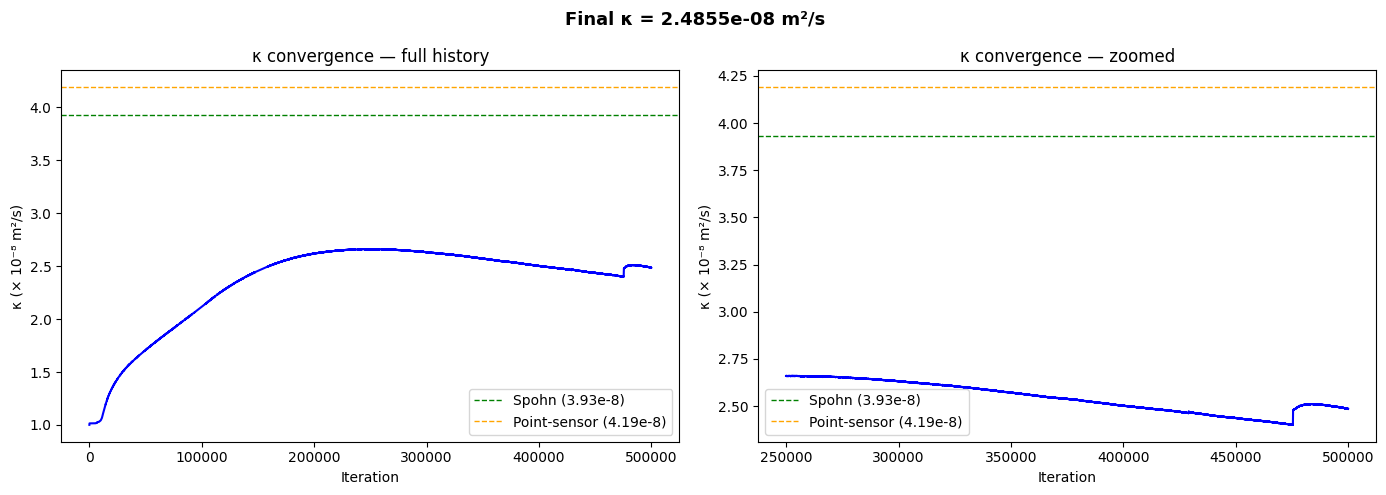

Final κ:          2.4855e-08 m²/s
Spohn reference:  3.93e-8 m²/s  (diff: -36.8%)


In [ ]:
# ── κ convergence plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

iters = jnp.arange(1, len(kappa_history) + 1)

# (a) Full history
axes[0].plot(iters, jnp.array(kappa_history) * 1e8, 'b-', lw=1.5)
axes[0].axhline(3.93, color='green', ls='--', lw=1, label='Spohn (3.93e-8)')
axes[0].axhline(4.19, color='orange', ls='--', lw=1, label='Point-sensor (4.19e-8)')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('κ (× 10⁻⁸ m²/s)')
axes[0].set_title('κ convergence — full history')
axes[0].legend()

# (b) Zoomed on last 50% to see plateau
half = len(kappa_history) // 2
axes[1].plot(iters[half:], jnp.array(kappa_history)[half:] * 1e8, 'b-', lw=1.5)
axes[1].axhline(3.93, color='green', ls='--', lw=1, label='Spohn (3.93e-8)')
axes[1].axhline(4.19, color='orange', ls='--', lw=1, label='Point-sensor (4.19e-8)')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('κ (× 10⁻⁸ m²/s)')
axes[1].set_title('κ convergence — zoomed')
axes[1].legend()

final_kappa = kappa_history[-1]
plt.suptitle(f'Final κ = {final_kappa:.4e} m²/s', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('point_sensor_graphs/kappa_convergence_ps_1e-8_run01.png', dpi=150)
plt.show()

print(f"Final κ:          {final_kappa:.4e} m²/s")
print(f"Spohn reference:  3.93e-8 m²/s  (diff: {(final_kappa - 3.93e-8)/3.93e-8 * 100:+.1f}%)")

In [ ]:
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import openpyxl
import optax

import jax.numpy as jnp

import copy
import pickle

# Problem parameters

depth = 0.4           # domain depth [m]
sol_seconds = 88775.244  # one sol [s]

avg_bottom_temp = 225.6  # average bottom temperature (K)
mole_depth = 0.094  # representative depth for diurnal signal [m]

# TEM-A Sol 1202 = mole temperature over one sol (the warmest sol sampled)
# RAD Sol 511   = surface temperature from radiometer (Spohn's proxy for sol 1202)

wb_diurnal = openpyxl.load_workbook(
    '../resources/data/Mars Soil Temperatures and Thermal Properties from Diurnal Wave data.xlsx',
    data_only=True
)

with open('checkpoints_point_sensor/ps_1e-8_run01.pkl', 'rb') as f:
    checkpoint = pickle.load(f)


kappa = checkpoint['final_kappa']


# --- Mole temperature (TEM-A Sol 1202) ---
ws_tem = wb_diurnal['TEM-A Sol 1202']
ltst_mole, temp_mole = [], []
for row in ws_tem.iter_rows(min_row=2, values_only=True):
    # Column index 6 = 'LTST Conversion step 2' (hours, 0-24)
    # Column index 7 = 'average T15, T16' (Kelvin)
    ltst_val = row[6]
    temp_val = row[7]
    if ltst_val is not None and temp_val is not None:
        try:
            t = float(ltst_val)
            T = float(temp_val)
            if 0 <= t <= 24 and 200 < T < 260:
                ltst_mole.append(t)
                temp_mole.append(T)
        except (ValueError, TypeError):
            pass


# --- Surface temperature (RAD Sol 511) ---
ws_rad = wb_diurnal['RAD SOL 511 D']
ltst_surf, temp_surf = [], []
for row in ws_rad.iter_rows(min_row=2, values_only=True):
    # Column index 4 = 'LTST converted' (hours)
    # Column index 5 = 'FOV 2 Temperature converted' (Kelvin)
    try:
        t = float(row[4])
        T = float(row[5])
        if 0 <= t <= 24 and 150 < T < 350:
            ltst_surf.append(t)
            temp_surf.append(T)
    except (ValueError, TypeError):
        pass

# Sort surface data by LTST (it may not be in order)
sorted_surf = sorted(zip(ltst_surf, temp_surf))
ltst_surf = [x[0] for x in sorted_surf]
temp_surf = [x[1] for x in sorted_surf]

# Conversion from hours to seconds for the time points. Make sure it is mapped correctly to the Mars sol time (0-88775.244 seconds)
ltst_mole = [t * sol_seconds / 24 for t in ltst_mole]
ltst_surf = [t * sol_seconds / 24 for t in ltst_surf]


# 1. Boundary Condition points (552 points each edge as we have 552 time points in the surface data)
n_surface = len(ltst_surf)  # Should be 552

# Surface boundary (x=0):
t_bc_surface = jnp.array(ltst_surf).reshape(-1, 1)  # (552, 1)
x_bc_surface = jnp.zeros((n_surface, 1))  # (552, 1)

u_bc_surface = jnp.array(temp_surf).reshape(-1, 1)  # (552, 1)

# Bottom boundary (x=depth):
t_bc_bottom = jnp.linspace(0, sol_seconds, n_surface).reshape(-1, 1)  # (552, 1)
x_bc_bottom = jnp.ones((n_surface, 1)) * depth

u_bc_bottom = jnp.ones((n_surface, 1)) * avg_bottom_temp  # (552, 1)

# Combine them:
t_bc = jnp.concatenate([t_bc_surface, t_bc_bottom])
x_bc = jnp.concatenate([x_bc_surface, x_bc_bottom])
u_bc = jnp.concatenate([u_bc_surface, u_bc_bottom])


# 2. Physics collocation points (100 * 100 = 10,000 points)
key = random.PRNGKey(0)
key1, key2 = random.split(key)
t_physics = random.uniform(key1, (10000, 1), minval=0, maxval=sol_seconds)
x_physics = random.uniform(key2, (10000, 1), minval=0, maxval=depth)


# 3. Data points for Data Loss (5550 points)
# We can use the mole temperature data as additional data points inside the domain (not just at the boundaries). This will help guide the network to learn the correct solution.

t_data = jnp.array(ltst_mole).reshape(-1, 1)
x_data = jnp.ones((len(ltst_mole), 1)) * mole_depth
u_data = jnp.array(temp_mole).reshape(-1, 1)


# Normalise the data so the network only sees values of order 1. This helps with training stability and convergence. We will need to un-normalise the predictions later to compare with the original data.

# Normalisation parameters
t_min, t_max = 0.0, sol_seconds
x_min, x_max = 0.0, depth
u_min, u_max = 185.0, 300.0  # Based on the range of temperatures in the data

def normalize_t(t): return ( t - t_min) / (t_max - t_min)
def normalize_x(x): return ( x - x_min) / (x_max - x_min)
def normalize_u(u): return ( u - u_min) / (u_max - u_min)

def unnormalize_u(u_norm): return u_norm * (u_max - u_min) + u_min

# Normalize all data
t_bc = normalize_t(t_bc)
x_bc = normalize_x(x_bc)
u_bc = normalize_u(u_bc)

t_physics = normalize_t(t_physics)
x_physics = normalize_x(x_physics)

t_data = normalize_t(t_data)
x_data = normalize_x(x_data)
u_data = normalize_u(u_data)

#Normalize kappa as well (since it appears in the physics residual)
def normalize_kappa(kappa):
    return kappa * (t_max - t_min) / ((x_max - x_min)**2)

# Neural Network

def init_network_params(layer_sizes, key):
    """
    Initialize parameters for a fully connected network.

    Args:
        layer_sizes: List of layer sizes, e.g., [2, 32, 32, 32, 1]
                    (input_dim, hidden1, hidden2, hidden3, output_dim)
        key: JAX random key for initialization

    Returns:
        params: idctionary containging the network list of dictionaries and log_kappa
    """
    # Split random key for each layer
    keys = random.split(key, len(layer_sizes))

    params = {}

    network = []
    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]

        # Split key for weights and biases
        w_key, b_key = random.split(keys[i])

        # Xavier initialization for weights
        network.append({
            'w': random.normal(w_key, (n_in, n_out)) * jnp.sqrt(2.0 / n_in),
            'b': jnp.zeros(n_out)
        })

    params['network'] = network
    params['log_kappa'] = jnp.log(kappa)  # Learn log(kappa) to ensure positivity

    return params


def network(params, x):
    """
    Forward pass through the network.

    Args:
        params: List of layer parameters (from init_network_params)
        x: Input array, shape (batch_size, input_dim)

    Returns:
        Output array, shape (batch_size, output_dim)
    """
    # Process all hidden layers (all but last)


    for layer in params['network'][:-1]:
        # Linear transformation: x @ W + b
        x = jnp.dot(x, layer['w']) + layer['b']
        # Activation function
        x = jnp.tanh(x)

    # Output layer (no activation)
    final_layer = params['network'][-1]
    x = jnp.dot(x, final_layer['w']) + final_layer['b']

    return x


# Calculate Residual

def physics_residual_single(params, t_point, x_point):

    def u(t_val, x_val):
        tx_in = jnp.array([[t_val, x_val]])
        return network(params, tx_in)[0, 0]

    du_dt = grad(u, argnums=0)(t_point, x_point)

    d2u_dx2 = grad(grad(u, argnums = 1), argnums=1)(t_point, x_point)

    kappa_eff = normalize_kappa(jnp.exp(params['log_kappa']))  # Ensure positivity

    return du_dt / kappa_eff - d2u_dx2


# Vectorize to handle all physics points at once
# So vmap will call physics_residual_single 10000 times, once for each (t, x) pair, keeping params fixed.
physics_residual_batch = vmap(physics_residual_single, in_axes=(None, 0, 0))


# Initialize network
key = random.PRNGKey(123)
layer_sizes = [2, 64, 64, 64, 64, 1]  # 2 inputs (t, x), 1 output (u)
params = checkpoint['params']

# Initialize optimizer
learning_rate = 1e-3
schedule = optax.piecewise_constant_schedule(init_value=learning_rate, boundaries_and_scales={60000: 0.1})
optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(params)


@jit
def update_step(params, opt_state,
                t_bc, x_bc, u_bc, t_physics, x_physics, t_data, x_data, u_data):

    def loss_fn(params):

        # 1. Boundary Condition Loss
        tx_bc = jnp.concatenate([t_bc, x_bc], axis=1)
        u_pred_bc = network(params, tx_bc)
        bc_loss = jnp.mean((u_pred_bc - u_bc)**2)

        # 2. Physics Loss
        physics_residuals = physics_residual_batch(params,
                                                t_physics.ravel(), # (10000,) not (10000, 1)
                                                x_physics.ravel()) # (10000,) not (10000, 1)
        physics_loss = jnp.mean(physics_residuals**2) # Physics residual is of 10000 points.

        # 3. Data Loss
        tx_data = jnp.concatenate([t_data, x_data], axis=1)
        u_pred_data = network(params, tx_data)
        data_loss = jnp.mean((u_pred_data - u_data)**2)

        return  bc_loss * 100 + physics_loss + data_loss * 50, (bc_loss, physics_loss, data_loss)

        # Compute loss and gradients
    (loss_val, individual_loss), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)

    # Update parameters
    updates, new_opt_state = optimizer.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)

    return new_params, new_opt_state, loss_val, individual_loss


# Training parameters
num_iterations = 500000
save_every = 150  # Save every 150 iterations
print_every = 1000

# Storage for snapshots
snapshots = []
snapshot_iterations = []

# Prepare physics points (flatten for vmap)
t_phys_flat = t_physics.ravel()
x_phys_flat = x_physics.ravel()

# Training loop
losses = []
losses_bc = []
losses_phys = []
losses_data = []
kappa_history = []
for i in range(num_iterations):
    params, opt_state, loss, individual_loss = update_step(
        params, opt_state,
        t_bc, x_bc, u_bc,
        t_phys_flat, x_phys_flat,
        t_data, x_data, u_data
    )

    losses.append(loss)
    losses_bc.append(individual_loss[0])
    losses_phys.append(individual_loss[1])
    losses_data.append(individual_loss[2])
    kappa_history.append(float(jnp.exp(params['log_kappa'])))


    # Save snapshot every 150 iterations
    if (i + 1) % save_every == 0:
        # Make a copy of params (important!)
        snapshots.append(copy.deepcopy(params))
        snapshot_iterations.append(i + 1)


    if (i + 1) % print_every == 0:
        print(f"Iteration {i+1}/{num_iterations}, Loss: {loss:.6f}")
        print(f"  BC Loss: {individual_loss[0]:.6f}, Physics Loss: {individual_loss[1]:.6f}, Data Loss: {individual_loss[2]:.6f}")
        print(f"  Current kappa: {jnp.exp(params['log_kappa']):.2e} m^2/s")


checkpoint = {
    # Learned parameters
    'params': jax.device_get(params),
    'opt_state': jax.device_get(opt_state),

    # Loss histories
    'losses': [float(l) for l in losses],
    'losses_bc': [float(l) for l in losses_bc],
    'losses_phys': [float(l) for l in losses_phys],
    'losses_data': [float(l) for l in losses_data],
    'kappa_history': kappa_history,

    # Snapshots for animation
    'snapshots': [jax.device_get(s) for s in snapshots],
    'snapshot_iterations': snapshot_iterations,

    # Training config (so you remember what produced this)
    'num_iterations': num_iterations,
    'layer_sizes': layer_sizes,
    'learning_rate': learning_rate,
    'final_kappa': float(jnp.exp(params['log_kappa'])),
}

with open('checkpoints_point_sensor/ps_1e-8_run02.pkl', 'wb') as f:
    pickle.dump(checkpoint, f)

print(f"Checkpoint saved. Final kappa: {jnp.exp(params['log_kappa']):.2e}")



Iteration 1000/500000, Loss: 0.024683
  BC Loss: 0.000009, Physics Loss: 0.006347, Data Loss: 0.000348
  Current kappa: 2.48e-08 m^2/s
Iteration 2000/500000, Loss: 0.020097
  BC Loss: 0.000009, Physics Loss: 0.001819, Data Loss: 0.000348
  Current kappa: 2.48e-08 m^2/s
Iteration 3000/500000, Loss: 0.027087
  BC Loss: 0.000012, Physics Loss: 0.008484, Data Loss: 0.000348
  Current kappa: 2.48e-08 m^2/s
Iteration 4000/500000, Loss: 0.023978
  BC Loss: 0.000008, Physics Loss: 0.005730, Data Loss: 0.000348
  Current kappa: 2.48e-08 m^2/s
Iteration 5000/500000, Loss: 0.020186
  BC Loss: 0.000008, Physics Loss: 0.001965, Data Loss: 0.000348
  Current kappa: 2.47e-08 m^2/s
Iteration 6000/500000, Loss: 0.023568
  BC Loss: 0.000008, Physics Loss: 0.005352, Data Loss: 0.000348
  Current kappa: 2.47e-08 m^2/s
Iteration 7000/500000, Loss: 0.062008
  BC Loss: 0.000012, Physics Loss: 0.043518, Data Loss: 0.000346
  Current kappa: 2.47e-08 m^2/s
Iteration 8000/500000, Loss: 0.031895
  BC Loss: 0.0000

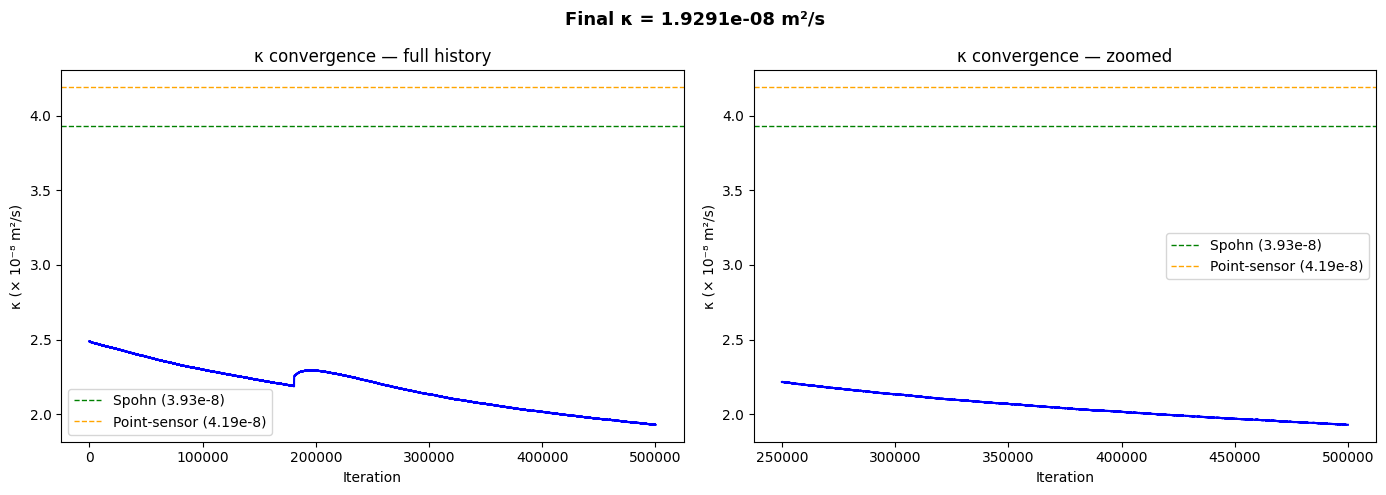

Final κ:          1.9291e-08 m²/s
Spohn reference:  3.93e-8 m²/s  (diff: -50.9%)


In [ ]:
# ── κ convergence plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

iters = jnp.arange(1, len(kappa_history) + 1)

# (a) Full history
axes[0].plot(iters, jnp.array(kappa_history) * 1e8, 'b-', lw=1.5)
axes[0].axhline(3.93, color='green', ls='--', lw=1, label='Spohn (3.93e-8)')
axes[0].axhline(4.19, color='orange', ls='--', lw=1, label='Point-sensor (4.19e-8)')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('κ (× 10⁻⁸ m²/s)')
axes[0].set_title('κ convergence — full history')
axes[0].legend()

# (b) Zoomed on last 50% to see plateau
half = len(kappa_history) // 2
axes[1].plot(iters[half:], jnp.array(kappa_history)[half:] * 1e8, 'b-', lw=1.5)
axes[1].axhline(3.93, color='green', ls='--', lw=1, label='Spohn (3.93e-8)')
axes[1].axhline(4.19, color='orange', ls='--', lw=1, label='Point-sensor (4.19e-8)')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('κ (× 10⁻⁸ m²/s)')
axes[1].set_title('κ convergence — zoomed')
axes[1].legend()

final_kappa = kappa_history[-1]
plt.suptitle(f'Final κ = {final_kappa:.4e} m²/s', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('point_sensor_graphs/kappa_convergence_ps_1e-8_run02.png', dpi=150)
plt.show()

print(f"Final κ:          {final_kappa:.4e} m²/s")
print(f"Spohn reference:  3.93e-8 m²/s  (diff: {(final_kappa - 3.93e-8)/3.93e-8 * 100:+.1f}%)")

In [ ]:
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import openpyxl
import optax

import jax.numpy as jnp

import copy
import pickle

# Problem parameters

depth = 0.4           # domain depth [m]
sol_seconds = 88775.244  # one sol [s]

avg_bottom_temp = 225.6  # average bottom temperature (K)
mole_depth = 0.094  # representative depth for diurnal signal [m]

# TEM-A Sol 1202 = mole temperature over one sol (the warmest sol sampled)
# RAD Sol 511   = surface temperature from radiometer (Spohn's proxy for sol 1202)

wb_diurnal = openpyxl.load_workbook(
    '../resources/data/Mars Soil Temperatures and Thermal Properties from Diurnal Wave data.xlsx',
    data_only=True
)

with open('checkpoints_point_sensor/ps_1e-8_run02.pkl', 'rb') as f:
    checkpoint = pickle.load(f)


kappa = checkpoint['final_kappa']


# --- Mole temperature (TEM-A Sol 1202) ---
ws_tem = wb_diurnal['TEM-A Sol 1202']
ltst_mole, temp_mole = [], []
for row in ws_tem.iter_rows(min_row=2, values_only=True):
    # Column index 6 = 'LTST Conversion step 2' (hours, 0-24)
    # Column index 7 = 'average T15, T16' (Kelvin)
    ltst_val = row[6]
    temp_val = row[7]
    if ltst_val is not None and temp_val is not None:
        try:
            t = float(ltst_val)
            T = float(temp_val)
            if 0 <= t <= 24 and 200 < T < 260:
                ltst_mole.append(t)
                temp_mole.append(T)
        except (ValueError, TypeError):
            pass


# --- Surface temperature (RAD Sol 511) ---
ws_rad = wb_diurnal['RAD SOL 511 D']
ltst_surf, temp_surf = [], []
for row in ws_rad.iter_rows(min_row=2, values_only=True):
    # Column index 4 = 'LTST converted' (hours)
    # Column index 5 = 'FOV 2 Temperature converted' (Kelvin)
    try:
        t = float(row[4])
        T = float(row[5])
        if 0 <= t <= 24 and 150 < T < 350:
            ltst_surf.append(t)
            temp_surf.append(T)
    except (ValueError, TypeError):
        pass

# Sort surface data by LTST (it may not be in order)
sorted_surf = sorted(zip(ltst_surf, temp_surf))
ltst_surf = [x[0] for x in sorted_surf]
temp_surf = [x[1] for x in sorted_surf]

# Conversion from hours to seconds for the time points. Make sure it is mapped correctly to the Mars sol time (0-88775.244 seconds)
ltst_mole = [t * sol_seconds / 24 for t in ltst_mole]
ltst_surf = [t * sol_seconds / 24 for t in ltst_surf]


# 1. Boundary Condition points (552 points each edge as we have 552 time points in the surface data)
n_surface = len(ltst_surf)  # Should be 552

# Surface boundary (x=0):
t_bc_surface = jnp.array(ltst_surf).reshape(-1, 1)  # (552, 1)
x_bc_surface = jnp.zeros((n_surface, 1))  # (552, 1)

u_bc_surface = jnp.array(temp_surf).reshape(-1, 1)  # (552, 1)

# Bottom boundary (x=depth):
t_bc_bottom = jnp.linspace(0, sol_seconds, n_surface).reshape(-1, 1)  # (552, 1)
x_bc_bottom = jnp.ones((n_surface, 1)) * depth

u_bc_bottom = jnp.ones((n_surface, 1)) * avg_bottom_temp  # (552, 1)

# Combine them:
t_bc = jnp.concatenate([t_bc_surface, t_bc_bottom])
x_bc = jnp.concatenate([x_bc_surface, x_bc_bottom])
u_bc = jnp.concatenate([u_bc_surface, u_bc_bottom])


# 2. Physics collocation points (100 * 100 = 10,000 points)
key = random.PRNGKey(0)
key1, key2 = random.split(key)
t_physics = random.uniform(key1, (10000, 1), minval=0, maxval=sol_seconds)
x_physics = random.uniform(key2, (10000, 1), minval=0, maxval=depth)


# 3. Data points for Data Loss (5550 points)
# We can use the mole temperature data as additional data points inside the domain (not just at the boundaries). This will help guide the network to learn the correct solution.

t_data = jnp.array(ltst_mole).reshape(-1, 1)
x_data = jnp.ones((len(ltst_mole), 1)) * mole_depth
u_data = jnp.array(temp_mole).reshape(-1, 1)


# Normalise the data so the network only sees values of order 1. This helps with training stability and convergence. We will need to un-normalise the predictions later to compare with the original data.

# Normalisation parameters
t_min, t_max = 0.0, sol_seconds
x_min, x_max = 0.0, depth
u_min, u_max = 185.0, 300.0  # Based on the range of temperatures in the data

def normalize_t(t): return ( t - t_min) / (t_max - t_min)
def normalize_x(x): return ( x - x_min) / (x_max - x_min)
def normalize_u(u): return ( u - u_min) / (u_max - u_min)

def unnormalize_u(u_norm): return u_norm * (u_max - u_min) + u_min

# Normalize all data
t_bc = normalize_t(t_bc)
x_bc = normalize_x(x_bc)
u_bc = normalize_u(u_bc)

t_physics = normalize_t(t_physics)
x_physics = normalize_x(x_physics)

t_data = normalize_t(t_data)
x_data = normalize_x(x_data)
u_data = normalize_u(u_data)

#Normalize kappa as well (since it appears in the physics residual)
def normalize_kappa(kappa):
    return kappa * (t_max - t_min) / ((x_max - x_min)**2)

# Neural Network

def init_network_params(layer_sizes, key):
    """
    Initialize parameters for a fully connected network.

    Args:
        layer_sizes: List of layer sizes, e.g., [2, 32, 32, 32, 1]
                    (input_dim, hidden1, hidden2, hidden3, output_dim)
        key: JAX random key for initialization

    Returns:
        params: idctionary containging the network list of dictionaries and log_kappa
    """
    # Split random key for each layer
    keys = random.split(key, len(layer_sizes))

    params = {}

    network = []
    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]

        # Split key for weights and biases
        w_key, b_key = random.split(keys[i])

        # Xavier initialization for weights
        network.append({
            'w': random.normal(w_key, (n_in, n_out)) * jnp.sqrt(2.0 / n_in),
            'b': jnp.zeros(n_out)
        })

    params['network'] = network
    params['log_kappa'] = jnp.log(kappa)  # Learn log(kappa) to ensure positivity

    return params


def network(params, x):
    """
    Forward pass through the network.

    Args:
        params: List of layer parameters (from init_network_params)
        x: Input array, shape (batch_size, input_dim)

    Returns:
        Output array, shape (batch_size, output_dim)
    """
    # Process all hidden layers (all but last)


    for layer in params['network'][:-1]:
        # Linear transformation: x @ W + b
        x = jnp.dot(x, layer['w']) + layer['b']
        # Activation function
        x = jnp.tanh(x)

    # Output layer (no activation)
    final_layer = params['network'][-1]
    x = jnp.dot(x, final_layer['w']) + final_layer['b']

    return x


# Calculate Residual

def physics_residual_single(params, t_point, x_point):

    def u(t_val, x_val):
        tx_in = jnp.array([[t_val, x_val]])
        return network(params, tx_in)[0, 0]

    du_dt = grad(u, argnums=0)(t_point, x_point)

    d2u_dx2 = grad(grad(u, argnums = 1), argnums=1)(t_point, x_point)

    kappa_eff = normalize_kappa(jnp.exp(params['log_kappa']))  # Ensure positivity

    return du_dt / kappa_eff - d2u_dx2


# Vectorize to handle all physics points at once
# So vmap will call physics_residual_single 10000 times, once for each (t, x) pair, keeping params fixed.
physics_residual_batch = vmap(physics_residual_single, in_axes=(None, 0, 0))


# Initialize network
key = random.PRNGKey(123)
layer_sizes = [2, 64, 64, 64, 64, 1]  # 2 inputs (t, x), 1 output (u)
params = checkpoint['params']

# Initialize optimizer
learning_rate = 1e-3
schedule = optax.piecewise_constant_schedule(init_value=learning_rate, boundaries_and_scales={60000: 0.1})
optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(params)


@jit
def update_step(params, opt_state,
                t_bc, x_bc, u_bc, t_physics, x_physics, t_data, x_data, u_data):

    def loss_fn(params):

        # 1. Boundary Condition Loss
        tx_bc = jnp.concatenate([t_bc, x_bc], axis=1)
        u_pred_bc = network(params, tx_bc)
        bc_loss = jnp.mean((u_pred_bc - u_bc)**2)

        # 2. Physics Loss
        physics_residuals = physics_residual_batch(params,
                                                t_physics.ravel(), # (10000,) not (10000, 1)
                                                x_physics.ravel()) # (10000,) not (10000, 1)
        physics_loss = jnp.mean(physics_residuals**2) # Physics residual is of 10000 points.

        # 3. Data Loss
        tx_data = jnp.concatenate([t_data, x_data], axis=1)
        u_pred_data = network(params, tx_data)
        data_loss = jnp.mean((u_pred_data - u_data)**2)

        return  bc_loss * 100 + physics_loss + data_loss * 50, (bc_loss, physics_loss, data_loss)

        # Compute loss and gradients
    (loss_val, individual_loss), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)

    # Update parameters
    updates, new_opt_state = optimizer.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)

    return new_params, new_opt_state, loss_val, individual_loss


# Training parameters
num_iterations = 1000000
save_every = 150  # Save every 150 iterations
print_every = 1000

# Storage for snapshots
snapshots = []
snapshot_iterations = []

# Prepare physics points (flatten for vmap)
t_phys_flat = t_physics.ravel()
x_phys_flat = x_physics.ravel()

# Training loop
losses = []
losses_bc = []
losses_phys = []
losses_data = []
kappa_history = []
for i in range(num_iterations):
    params, opt_state, loss, individual_loss = update_step(
        params, opt_state,
        t_bc, x_bc, u_bc,
        t_phys_flat, x_phys_flat,
        t_data, x_data, u_data
    )

    losses.append(loss)
    losses_bc.append(individual_loss[0])
    losses_phys.append(individual_loss[1])
    losses_data.append(individual_loss[2])
    kappa_history.append(float(jnp.exp(params['log_kappa'])))


    # Save snapshot every 150 iterations
    if (i + 1) % save_every == 0:
        # Make a copy of params (important!)
        snapshots.append(copy.deepcopy(params))
        snapshot_iterations.append(i + 1)


    if (i + 1) % print_every == 0:
        print(f"Iteration {i+1}/{num_iterations}, Loss: {loss:.6f}")
        print(f"  BC Loss: {individual_loss[0]:.6f}, Physics Loss: {individual_loss[1]:.6f}, Data Loss: {individual_loss[2]:.6f}")
        print(f"  Current kappa: {jnp.exp(params['log_kappa']):.2e} m^2/s")


checkpoint = {
    # Learned parameters
    'params': jax.device_get(params),
    'opt_state': jax.device_get(opt_state),

    # Loss histories
    'losses': [float(l) for l in losses],
    'losses_bc': [float(l) for l in losses_bc],
    'losses_phys': [float(l) for l in losses_phys],
    'losses_data': [float(l) for l in losses_data],
    'kappa_history': kappa_history,

    # Snapshots for animation
    'snapshots': [jax.device_get(s) for s in snapshots],
    'snapshot_iterations': snapshot_iterations,

    # Training config (so you remember what produced this)
    'num_iterations': num_iterations,
    'layer_sizes': layer_sizes,
    'learning_rate': learning_rate,
    'final_kappa': float(jnp.exp(params['log_kappa'])),
}

with open('checkpoints_point_sensor/ps_1e-8_run03.pkl', 'wb') as f:
    pickle.dump(checkpoint, f)

print(f"Checkpoint saved. Final kappa: {jnp.exp(params['log_kappa']):.2e}")



Iteration 1000/1000000, Loss: 0.015016
  BC Loss: 0.000003, Physics Loss: 0.001087, Data Loss: 0.000273
  Current kappa: 1.93e-08 m^2/s
Iteration 2000/1000000, Loss: 0.019418
  BC Loss: 0.000003, Physics Loss: 0.005495, Data Loss: 0.000272
  Current kappa: 1.93e-08 m^2/s
Iteration 3000/1000000, Loss: 0.022572
  BC Loss: 0.000009, Physics Loss: 0.007516, Data Loss: 0.000282
  Current kappa: 1.93e-08 m^2/s
Iteration 4000/1000000, Loss: 0.020070
  BC Loss: 0.000004, Physics Loss: 0.005990, Data Loss: 0.000274
  Current kappa: 1.93e-08 m^2/s
Iteration 5000/1000000, Loss: 0.015865
  BC Loss: 0.000003, Physics Loss: 0.001994, Data Loss: 0.000272
  Current kappa: 1.92e-08 m^2/s
Iteration 6000/1000000, Loss: 0.017278
  BC Loss: 0.000005, Physics Loss: 0.003104, Data Loss: 0.000273
  Current kappa: 1.92e-08 m^2/s
Iteration 7000/1000000, Loss: 0.019611
  BC Loss: 0.000003, Physics Loss: 0.005730, Data Loss: 0.000271
  Current kappa: 1.92e-08 m^2/s
Iteration 8000/1000000, Loss: 0.023406
  BC Loss

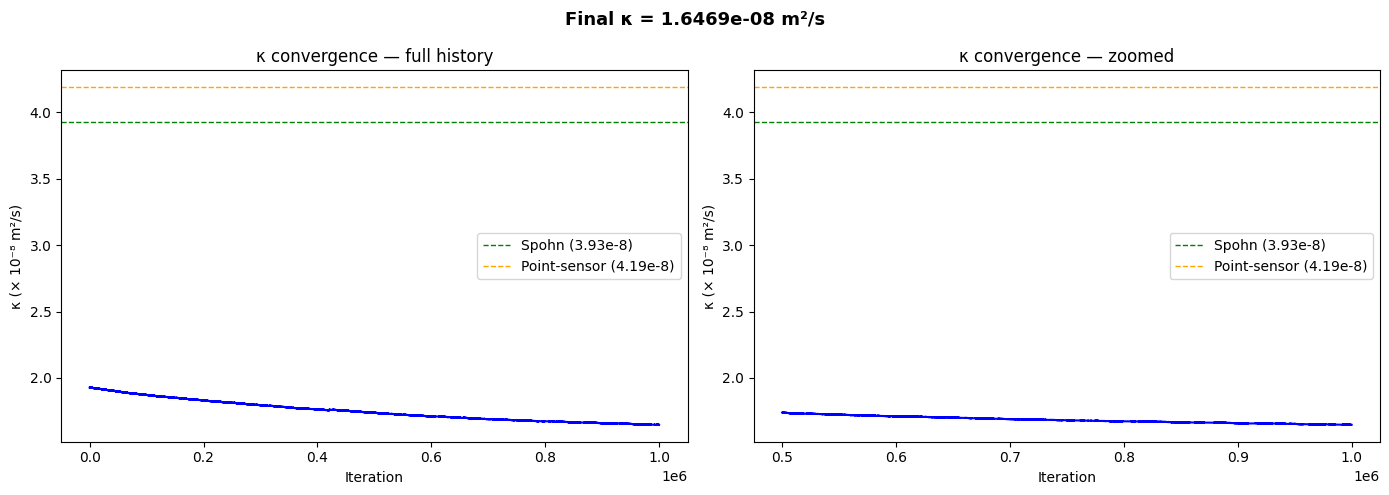

Final κ:          1.6469e-08 m²/s
Spohn reference:  3.93e-8 m²/s  (diff: -58.1%)


In [ ]:
# ── κ convergence plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

iters = jnp.arange(1, len(kappa_history) + 1)

# (a) Full history
axes[0].plot(iters, jnp.array(kappa_history) * 1e8, 'b-', lw=1.5)
axes[0].axhline(3.93, color='green', ls='--', lw=1, label='Spohn (3.93e-8)')
axes[0].axhline(4.19, color='orange', ls='--', lw=1, label='Point-sensor (4.19e-8)')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('κ (× 10⁻⁸ m²/s)')
axes[0].set_title('κ convergence — full history')
axes[0].legend()

# (b) Zoomed on last 50% to see plateau
half = len(kappa_history) // 2
axes[1].plot(iters[half:], jnp.array(kappa_history)[half:] * 1e8, 'b-', lw=1.5)
axes[1].axhline(3.93, color='green', ls='--', lw=1, label='Spohn (3.93e-8)')
axes[1].axhline(4.19, color='orange', ls='--', lw=1, label='Point-sensor (4.19e-8)')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('κ (× 10⁻⁸ m²/s)')
axes[1].set_title('κ convergence — zoomed')
axes[1].legend()

final_kappa = kappa_history[-1]
plt.suptitle(f'Final κ = {final_kappa:.4e} m²/s', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('point_sensor_graphs/kappa_convergence_ps_1e-8_run03.png', dpi=150)
plt.show()

print(f"Final κ:          {final_kappa:.4e} m²/s")
print(f"Spohn reference:  3.93e-8 m²/s  (diff: {(final_kappa - 3.93e-8)/3.93e-8 * 100:+.1f}%)")

# **Verify 5e-9**

In [ ]:
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import openpyxl
import optax

import jax.numpy as jnp

import copy
import pickle

# Problem parameters
kappa = 5e-9      # thermal diffusivity [m^2/s]. Intial guess for the inverse problem (Spohn's value). We will learn this parameter.
depth = 0.4           # domain depth [m]
sol_seconds = 88775.244  # one sol [s]

avg_bottom_temp = 225.6  # average bottom temperature (K)
mole_depth = 0.094  # representative depth for diurnal signal [m]

# TEM-A Sol 1202 = mole temperature over one sol (the warmest sol sampled)
# RAD Sol 511   = surface temperature from radiometer (Spohn's proxy for sol 1202)

wb_diurnal = openpyxl.load_workbook(
    '../resources/data/Mars Soil Temperatures and Thermal Properties from Diurnal Wave data.xlsx',
    data_only=True
)

# --- Mole temperature (TEM-A Sol 1202) ---
ws_tem = wb_diurnal['TEM-A Sol 1202']
ltst_mole, temp_mole = [], []
for row in ws_tem.iter_rows(min_row=2, values_only=True):
    # Column index 6 = 'LTST Conversion step 2' (hours, 0-24)
    # Column index 7 = 'average T15, T16' (Kelvin)
    ltst_val = row[6]
    temp_val = row[7]
    if ltst_val is not None and temp_val is not None:
        try:
            t = float(ltst_val)
            T = float(temp_val)
            if 0 <= t <= 24 and 200 < T < 260:
                ltst_mole.append(t)
                temp_mole.append(T)
        except (ValueError, TypeError):
            pass


# --- Surface temperature (RAD Sol 511) ---
ws_rad = wb_diurnal['RAD SOL 511 D']
ltst_surf, temp_surf = [], []
for row in ws_rad.iter_rows(min_row=2, values_only=True):
    # Column index 4 = 'LTST converted' (hours)
    # Column index 5 = 'FOV 2 Temperature converted' (Kelvin)
    try:
        t = float(row[4])
        T = float(row[5])
        if 0 <= t <= 24 and 150 < T < 350:
            ltst_surf.append(t)
            temp_surf.append(T)
    except (ValueError, TypeError):
        pass

# Sort surface data by LTST (it may not be in order)
sorted_surf = sorted(zip(ltst_surf, temp_surf))
ltst_surf = [x[0] for x in sorted_surf]
temp_surf = [x[1] for x in sorted_surf]

# Conversion from hours to seconds for the time points. Make sure it is mapped correctly to the Mars sol time (0-88775.244 seconds)
ltst_mole = [t * sol_seconds / 24 for t in ltst_mole]
ltst_surf = [t * sol_seconds / 24 for t in ltst_surf]


# 1. Boundary Condition points (552 points each edge as we have 552 time points in the surface data)
n_surface = len(ltst_surf)  # Should be 552

# Surface boundary (x=0):
t_bc_surface = jnp.array(ltst_surf).reshape(-1, 1)  # (552, 1)
x_bc_surface = jnp.zeros((n_surface, 1))  # (552, 1)

u_bc_surface = jnp.array(temp_surf).reshape(-1, 1)  # (552, 1)

# Bottom boundary (x=depth):
t_bc_bottom = jnp.linspace(0, sol_seconds, n_surface).reshape(-1, 1)  # (552, 1)
x_bc_bottom = jnp.ones((n_surface, 1)) * depth

u_bc_bottom = jnp.ones((n_surface, 1)) * avg_bottom_temp  # (552, 1)

# Combine them:
t_bc = jnp.concatenate([t_bc_surface, t_bc_bottom])
x_bc = jnp.concatenate([x_bc_surface, x_bc_bottom])
u_bc = jnp.concatenate([u_bc_surface, u_bc_bottom])


# 2. Physics collocation points (100 * 100 = 10,000 points)
key = random.PRNGKey(0)
key1, key2 = random.split(key)
t_physics = random.uniform(key1, (10000, 1), minval=0, maxval=sol_seconds)
x_physics = random.uniform(key2, (10000, 1), minval=0, maxval=depth)


# 3. Data points for Data Loss (5550 points)
# We can use the mole temperature data as additional data points inside the domain (not just at the boundaries). This will help guide the network to learn the correct solution.

t_data = jnp.array(ltst_mole).reshape(-1, 1)
x_data = jnp.ones((len(ltst_mole), 1)) * mole_depth
u_data = jnp.array(temp_mole).reshape(-1, 1)


# Normalise the data so the network only sees values of order 1. This helps with training stability and convergence. We will need to un-normalise the predictions later to compare with the original data.

# Normalisation parameters
t_min, t_max = 0.0, sol_seconds
x_min, x_max = 0.0, depth
u_min, u_max = 185.0, 300.0  # Based on the range of temperatures in the data

def normalize_t(t): return ( t - t_min) / (t_max - t_min)
def normalize_x(x): return ( x - x_min) / (x_max - x_min)
def normalize_u(u): return ( u - u_min) / (u_max - u_min)

def unnormalize_u(u_norm): return u_norm * (u_max - u_min) + u_min

# Normalize all data
t_bc = normalize_t(t_bc)
x_bc = normalize_x(x_bc)
u_bc = normalize_u(u_bc)

t_physics = normalize_t(t_physics)
x_physics = normalize_x(x_physics)

t_data = normalize_t(t_data)
x_data = normalize_x(x_data)
u_data = normalize_u(u_data)

#Normalize kappa as well (since it appears in the physics residual)
def normalize_kappa(kappa):
    return kappa * (t_max - t_min) / ((x_max - x_min)**2)

# Neural Network

def init_network_params(layer_sizes, key):
    """
    Initialize parameters for a fully connected network.

    Args:
        layer_sizes: List of layer sizes, e.g., [2, 32, 32, 32, 1]
                    (input_dim, hidden1, hidden2, hidden3, output_dim)
        key: JAX random key for initialization

    Returns:
        params: idctionary containging the network list of dictionaries and log_kappa
    """
    # Split random key for each layer
    keys = random.split(key, len(layer_sizes))

    params = {}

    network = []
    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]

        # Split key for weights and biases
        w_key, b_key = random.split(keys[i])

        # Xavier initialization for weights
        network.append({
            'w': random.normal(w_key, (n_in, n_out)) * jnp.sqrt(2.0 / n_in),
            'b': jnp.zeros(n_out)
        })

    params['network'] = network
    params['log_kappa'] = jnp.log(kappa)  # Learn log(kappa) to ensure positivity

    return params


def network(params, x):
    """
    Forward pass through the network.

    Args:
        params: List of layer parameters (from init_network_params)
        x: Input array, shape (batch_size, input_dim)

    Returns:
        Output array, shape (batch_size, output_dim)
    """
    # Process all hidden layers (all but last)


    for layer in params['network'][:-1]:
        # Linear transformation: x @ W + b
        x = jnp.dot(x, layer['w']) + layer['b']
        # Activation function
        x = jnp.tanh(x)

    # Output layer (no activation)
    final_layer = params['network'][-1]
    x = jnp.dot(x, final_layer['w']) + final_layer['b']

    return x


# Calculate Residual

def physics_residual_single(params, t_point, x_point):

    def u(t_val, x_val):
        tx_in = jnp.array([[t_val, x_val]])
        return network(params, tx_in)[0, 0]

    du_dt = grad(u, argnums=0)(t_point, x_point)

    d2u_dx2 = grad(grad(u, argnums = 1), argnums=1)(t_point, x_point)

    kappa_eff = normalize_kappa(jnp.exp(params['log_kappa']))  # Ensure positivity

    return du_dt / kappa_eff - d2u_dx2


# Vectorize to handle all physics points at once
# So vmap will call physics_residual_single 10000 times, once for each (t, x) pair, keeping params fixed.
physics_residual_batch = vmap(physics_residual_single, in_axes=(None, 0, 0))


# Initialize network
key = random.PRNGKey(123)
layer_sizes = [2, 64, 64, 64, 64, 1]  # 2 inputs (t, x), 1 output (u)
params = init_network_params(layer_sizes, key)

# Initialize optimizer
learning_rate = 1e-3
schedule = optax.piecewise_constant_schedule(init_value=learning_rate, boundaries_and_scales={60000: 0.1})
optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(params)


@jit
def update_step(params, opt_state,
                t_bc, x_bc, u_bc, t_physics, x_physics, t_data, x_data, u_data):

    def loss_fn(params):

        # 1. Boundary Condition Loss
        tx_bc = jnp.concatenate([t_bc, x_bc], axis=1)
        u_pred_bc = network(params, tx_bc)
        bc_loss = jnp.mean((u_pred_bc - u_bc)**2)

        # 2. Physics Loss
        physics_residuals = physics_residual_batch(params,
                                                t_physics.ravel(), # (10000,) not (10000, 1)
                                                x_physics.ravel()) # (10000,) not (10000, 1)
        physics_loss = jnp.mean(physics_residuals**2) # Physics residual is of 10000 points.

        # 3. Data Loss
        tx_data = jnp.concatenate([t_data, x_data], axis=1)
        u_pred_data = network(params, tx_data)
        data_loss = jnp.mean((u_pred_data - u_data)**2)

        return  bc_loss * 100 + physics_loss + data_loss * 50, (bc_loss, physics_loss, data_loss)

        # Compute loss and gradients
    (loss_val, individual_loss), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)

    # Update parameters
    updates, new_opt_state = optimizer.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)

    return new_params, new_opt_state, loss_val, individual_loss


# Training parameters
num_iterations = 1000000
save_every = 150  # Save every 150 iterations
print_every = 1000

# Storage for snapshots
snapshots = []
snapshot_iterations = []

# Prepare physics points (flatten for vmap)
t_phys_flat = t_physics.ravel()
x_phys_flat = x_physics.ravel()

# Training loop
losses = []
losses_bc = []
losses_phys = []
losses_data = []
kappa_history = []
for i in range(num_iterations):
    params, opt_state, loss, individual_loss = update_step(
        params, opt_state,
        t_bc, x_bc, u_bc,
        t_phys_flat, x_phys_flat,
        t_data, x_data, u_data
    )

    losses.append(loss)
    losses_bc.append(individual_loss[0])
    losses_phys.append(individual_loss[1])
    losses_data.append(individual_loss[2])
    kappa_history.append(float(jnp.exp(params['log_kappa'])))


    # Save snapshot every 150 iterations
    if (i + 1) % save_every == 0:
        # Make a copy of params (important!)
        snapshots.append(copy.deepcopy(params))
        snapshot_iterations.append(i + 1)


    if (i + 1) % print_every == 0:
        print(f"Iteration {i+1}/{num_iterations}, Loss: {loss:.6f}")
        print(f"  BC Loss: {individual_loss[0]:.6f}, Physics Loss: {individual_loss[1]:.6f}, Data Loss: {individual_loss[2]:.6f}")
        print(f"  Current kappa: {jnp.exp(params['log_kappa']):.2e} m^2/s")


checkpoint = {
    # Learned parameters
    'params': jax.device_get(params),
    'opt_state': jax.device_get(opt_state),

    # Loss histories
    'losses': [float(l) for l in losses],
    'losses_bc': [float(l) for l in losses_bc],
    'losses_phys': [float(l) for l in losses_phys],
    'losses_data': [float(l) for l in losses_data],
    'kappa_history': kappa_history,

    # Snapshots for animation
    'snapshots': [jax.device_get(s) for s in snapshots],
    'snapshot_iterations': snapshot_iterations,

    # Training config (so you remember what produced this)
    'num_iterations': num_iterations,
    'layer_sizes': layer_sizes,
    'learning_rate': learning_rate,
    'final_kappa': float(jnp.exp(params['log_kappa'])),
}

with open('checkpoints_point_sensor/ps_5e-9_run01.pkl', 'wb') as f:
    pickle.dump(checkpoint, f)

print(f"Checkpoint saved. Final kappa: {jnp.exp(params['log_kappa']):.2e}")



/usr/local/lib/python3.12/dist-packages/openpyxl/reader/drawings.py:67: UserWarning: wmf image format is not supported so the image is being dropped
  warn(msg)


Iteration 1000/1000000, Loss: 8.510846
  BC Loss: 0.056747, Physics Loss: 2.578241, Data Loss: 0.005159
  Current kappa: 5.07e-09 m^2/s
Iteration 2000/1000000, Loss: 6.848035
  BC Loss: 0.056449, Physics Loss: 0.997972, Data Loss: 0.004103
  Current kappa: 5.07e-09 m^2/s
Iteration 3000/1000000, Loss: 6.327213
  BC Loss: 0.056120, Physics Loss: 0.578649, Data Loss: 0.002731
  Current kappa: 5.07e-09 m^2/s
Iteration 4000/1000000, Loss: 5.983136
  BC Loss: 0.055760, Physics Loss: 0.329467, Data Loss: 0.001553
  Current kappa: 5.07e-09 m^2/s
Iteration 5000/1000000, Loss: 5.767482
  BC Loss: 0.055542, Physics Loss: 0.173025, Data Loss: 0.000806
  Current kappa: 5.07e-09 m^2/s
Iteration 6000/1000000, Loss: 6.823124
  BC Loss: 0.055172, Physics Loss: 1.281544, Data Loss: 0.000489
  Current kappa: 5.10e-09 m^2/s
Iteration 7000/1000000, Loss: 5.642169
  BC Loss: 0.055185, Physics Loss: 0.099987, Data Loss: 0.000474
  Current kappa: 5.12e-09 m^2/s
Iteration 8000/1000000, Loss: 5.738796
  BC Loss

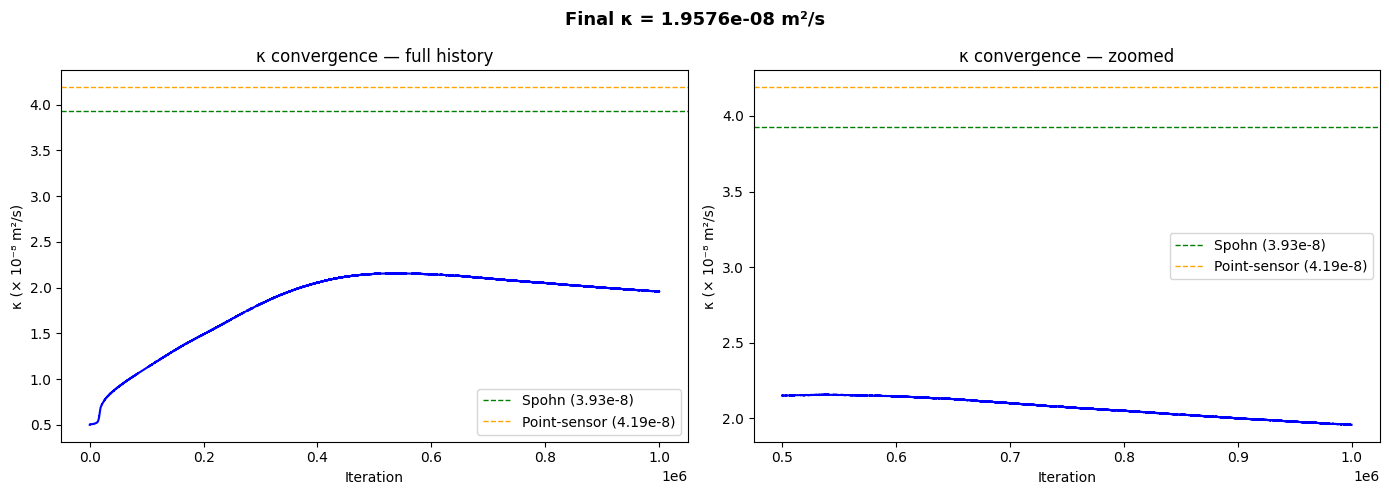

Final κ:          1.9576e-08 m²/s
Spohn reference:  3.93e-8 m²/s  (diff: -50.2%)


In [ ]:
import pickle
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp


with open('checkpoints_point_sensor/ps_5e-9_run01.pkl', 'rb') as f:
    checkpoint = pickle.load(f)

kappa_history = checkpoint['kappa_history']

# ── κ convergence plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

iters = jnp.arange(1, len(kappa_history) + 1)

# (a) Full history
axes[0].plot(iters, jnp.array(kappa_history) * 1e8, 'b-', lw=1.5)
axes[0].axhline(3.93, color='green', ls='--', lw=1, label='Spohn (3.93e-8)')
axes[0].axhline(4.19, color='orange', ls='--', lw=1, label='Point-sensor (4.19e-8)')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('κ (× 10⁻⁸ m²/s)')
axes[0].set_title('κ convergence — full history')
axes[0].legend()

# (b) Zoomed on last 50% to see plateau
half = len(kappa_history) // 2
axes[1].plot(iters[half:], jnp.array(kappa_history)[half:] * 1e8, 'b-', lw=1.5)
axes[1].axhline(3.93, color='green', ls='--', lw=1, label='Spohn (3.93e-8)')
axes[1].axhline(4.19, color='orange', ls='--', lw=1, label='Point-sensor (4.19e-8)')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('κ (× 10⁻⁸ m²/s)')
axes[1].set_title('κ convergence — zoomed')
axes[1].legend()

final_kappa = kappa_history[-1]
plt.suptitle(f'Final κ = {final_kappa:.4e} m²/s', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('point_sensor_graphs/kappa_convergence_ps_5e-9_run01.png', dpi=150)
plt.show()

print(f"Final κ:          {final_kappa:.4e} m²/s")
print(f"Spohn reference:  3.93e-8 m²/s  (diff: {(final_kappa - 3.93e-8)/3.93e-8 * 100:+.1f}%)")

# **Verify 1e-9**

In [ ]:
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import openpyxl
import optax

import jax.numpy as jnp

import copy
import pickle

# Problem parameters
kappa = 1e-9      # thermal diffusivity [m^2/s]. Intial guess for the inverse problem (Spohn's value). We will learn this parameter.
depth = 0.4           # domain depth [m]
sol_seconds = 88775.244  # one sol [s]

avg_bottom_temp = 225.6  # average bottom temperature (K)
mole_depth = 0.094  # representative depth for diurnal signal [m]

# TEM-A Sol 1202 = mole temperature over one sol (the warmest sol sampled)
# RAD Sol 511   = surface temperature from radiometer (Spohn's proxy for sol 1202)

wb_diurnal = openpyxl.load_workbook(
    '../resources/data/Mars Soil Temperatures and Thermal Properties from Diurnal Wave data.xlsx',
    data_only=True
)

# --- Mole temperature (TEM-A Sol 1202) ---
ws_tem = wb_diurnal['TEM-A Sol 1202']
ltst_mole, temp_mole = [], []
for row in ws_tem.iter_rows(min_row=2, values_only=True):
    # Column index 6 = 'LTST Conversion step 2' (hours, 0-24)
    # Column index 7 = 'average T15, T16' (Kelvin)
    ltst_val = row[6]
    temp_val = row[7]
    if ltst_val is not None and temp_val is not None:
        try:
            t = float(ltst_val)
            T = float(temp_val)
            if 0 <= t <= 24 and 200 < T < 260:
                ltst_mole.append(t)
                temp_mole.append(T)
        except (ValueError, TypeError):
            pass


# --- Surface temperature (RAD Sol 511) ---
ws_rad = wb_diurnal['RAD SOL 511 D']
ltst_surf, temp_surf = [], []
for row in ws_rad.iter_rows(min_row=2, values_only=True):
    # Column index 4 = 'LTST converted' (hours)
    # Column index 5 = 'FOV 2 Temperature converted' (Kelvin)
    try:
        t = float(row[4])
        T = float(row[5])
        if 0 <= t <= 24 and 150 < T < 350:
            ltst_surf.append(t)
            temp_surf.append(T)
    except (ValueError, TypeError):
        pass

# Sort surface data by LTST (it may not be in order)
sorted_surf = sorted(zip(ltst_surf, temp_surf))
ltst_surf = [x[0] for x in sorted_surf]
temp_surf = [x[1] for x in sorted_surf]

# Conversion from hours to seconds for the time points. Make sure it is mapped correctly to the Mars sol time (0-88775.244 seconds)
ltst_mole = [t * sol_seconds / 24 for t in ltst_mole]
ltst_surf = [t * sol_seconds / 24 for t in ltst_surf]


# 1. Boundary Condition points (552 points each edge as we have 552 time points in the surface data)
n_surface = len(ltst_surf)  # Should be 552

# Surface boundary (x=0):
t_bc_surface = jnp.array(ltst_surf).reshape(-1, 1)  # (552, 1)
x_bc_surface = jnp.zeros((n_surface, 1))  # (552, 1)

u_bc_surface = jnp.array(temp_surf).reshape(-1, 1)  # (552, 1)

# Bottom boundary (x=depth):
t_bc_bottom = jnp.linspace(0, sol_seconds, n_surface).reshape(-1, 1)  # (552, 1)
x_bc_bottom = jnp.ones((n_surface, 1)) * depth

u_bc_bottom = jnp.ones((n_surface, 1)) * avg_bottom_temp  # (552, 1)

# Combine them:
t_bc = jnp.concatenate([t_bc_surface, t_bc_bottom])
x_bc = jnp.concatenate([x_bc_surface, x_bc_bottom])
u_bc = jnp.concatenate([u_bc_surface, u_bc_bottom])


# 2. Physics collocation points (100 * 100 = 10,000 points)
key = random.PRNGKey(0)
key1, key2 = random.split(key)
t_physics = random.uniform(key1, (10000, 1), minval=0, maxval=sol_seconds)
x_physics = random.uniform(key2, (10000, 1), minval=0, maxval=depth)


# 3. Data points for Data Loss (5550 points)
# We can use the mole temperature data as additional data points inside the domain (not just at the boundaries). This will help guide the network to learn the correct solution.

t_data = jnp.array(ltst_mole).reshape(-1, 1)
x_data = jnp.ones((len(ltst_mole), 1)) * mole_depth
u_data = jnp.array(temp_mole).reshape(-1, 1)


# Normalise the data so the network only sees values of order 1. This helps with training stability and convergence. We will need to un-normalise the predictions later to compare with the original data.

# Normalisation parameters
t_min, t_max = 0.0, sol_seconds
x_min, x_max = 0.0, depth
u_min, u_max = 185.0, 300.0  # Based on the range of temperatures in the data

def normalize_t(t): return ( t - t_min) / (t_max - t_min)
def normalize_x(x): return ( x - x_min) / (x_max - x_min)
def normalize_u(u): return ( u - u_min) / (u_max - u_min)

def unnormalize_u(u_norm): return u_norm * (u_max - u_min) + u_min

# Normalize all data
t_bc = normalize_t(t_bc)
x_bc = normalize_x(x_bc)
u_bc = normalize_u(u_bc)

t_physics = normalize_t(t_physics)
x_physics = normalize_x(x_physics)

t_data = normalize_t(t_data)
x_data = normalize_x(x_data)
u_data = normalize_u(u_data)

#Normalize kappa as well (since it appears in the physics residual)
def normalize_kappa(kappa):
    return kappa * (t_max - t_min) / ((x_max - x_min)**2)

# Neural Network

def init_network_params(layer_sizes, key):
    """
    Initialize parameters for a fully connected network.

    Args:
        layer_sizes: List of layer sizes, e.g., [2, 32, 32, 32, 1]
                    (input_dim, hidden1, hidden2, hidden3, output_dim)
        key: JAX random key for initialization

    Returns:
        params: idctionary containging the network list of dictionaries and log_kappa
    """
    # Split random key for each layer
    keys = random.split(key, len(layer_sizes))

    params = {}

    network = []
    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]

        # Split key for weights and biases
        w_key, b_key = random.split(keys[i])

        # Xavier initialization for weights
        network.append({
            'w': random.normal(w_key, (n_in, n_out)) * jnp.sqrt(2.0 / n_in),
            'b': jnp.zeros(n_out)
        })

    params['network'] = network
    params['log_kappa'] = jnp.log(kappa)  # Learn log(kappa) to ensure positivity

    return params


def network(params, x):
    """
    Forward pass through the network.

    Args:
        params: List of layer parameters (from init_network_params)
        x: Input array, shape (batch_size, input_dim)

    Returns:
        Output array, shape (batch_size, output_dim)
    """
    # Process all hidden layers (all but last)


    for layer in params['network'][:-1]:
        # Linear transformation: x @ W + b
        x = jnp.dot(x, layer['w']) + layer['b']
        # Activation function
        x = jnp.tanh(x)

    # Output layer (no activation)
    final_layer = params['network'][-1]
    x = jnp.dot(x, final_layer['w']) + final_layer['b']

    return x


# Calculate Residual

def physics_residual_single(params, t_point, x_point):

    def u(t_val, x_val):
        tx_in = jnp.array([[t_val, x_val]])
        return network(params, tx_in)[0, 0]

    du_dt = grad(u, argnums=0)(t_point, x_point)

    d2u_dx2 = grad(grad(u, argnums = 1), argnums=1)(t_point, x_point)

    kappa_eff = normalize_kappa(jnp.exp(params['log_kappa']))  # Ensure positivity

    return du_dt / kappa_eff - d2u_dx2


# Vectorize to handle all physics points at once
# So vmap will call physics_residual_single 10000 times, once for each (t, x) pair, keeping params fixed.
physics_residual_batch = vmap(physics_residual_single, in_axes=(None, 0, 0))


# Initialize network
key = random.PRNGKey(123)
layer_sizes = [2, 64, 64, 64, 64, 1]  # 2 inputs (t, x), 1 output (u)
params = init_network_params(layer_sizes, key)

# Initialize optimizer
learning_rate = 1e-3
schedule = optax.piecewise_constant_schedule(init_value=learning_rate, boundaries_and_scales={60000: 0.1})
optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(params)


@jit
def update_step(params, opt_state,
                t_bc, x_bc, u_bc, t_physics, x_physics, t_data, x_data, u_data):

    def loss_fn(params):

        # 1. Boundary Condition Loss
        tx_bc = jnp.concatenate([t_bc, x_bc], axis=1)
        u_pred_bc = network(params, tx_bc)
        bc_loss = jnp.mean((u_pred_bc - u_bc)**2)

        # 2. Physics Loss
        physics_residuals = physics_residual_batch(params,
                                                t_physics.ravel(), # (10000,) not (10000, 1)
                                                x_physics.ravel()) # (10000,) not (10000, 1)
        physics_loss = jnp.mean(physics_residuals**2) # Physics residual is of 10000 points.

        # 3. Data Loss
        tx_data = jnp.concatenate([t_data, x_data], axis=1)
        u_pred_data = network(params, tx_data)
        data_loss = jnp.mean((u_pred_data - u_data)**2)

        return  bc_loss * 100 + physics_loss + data_loss * 50, (bc_loss, physics_loss, data_loss)

        # Compute loss and gradients
    (loss_val, individual_loss), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)

    # Update parameters
    updates, new_opt_state = optimizer.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)

    return new_params, new_opt_state, loss_val, individual_loss


# Training parameters
num_iterations = 1000000
save_every = 150  # Save every 150 iterations
print_every = 1000

# Storage for snapshots
snapshots = []
snapshot_iterations = []

# Prepare physics points (flatten for vmap)
t_phys_flat = t_physics.ravel()
x_phys_flat = x_physics.ravel()

# Training loop
losses = []
losses_bc = []
losses_phys = []
losses_data = []
kappa_history = []
for i in range(num_iterations):
    params, opt_state, loss, individual_loss = update_step(
        params, opt_state,
        t_bc, x_bc, u_bc,
        t_phys_flat, x_phys_flat,
        t_data, x_data, u_data
    )

    losses.append(loss)
    losses_bc.append(individual_loss[0])
    losses_phys.append(individual_loss[1])
    losses_data.append(individual_loss[2])
    kappa_history.append(float(jnp.exp(params['log_kappa'])))


    # Save snapshot every 150 iterations
    if (i + 1) % save_every == 0:
        # Make a copy of params (important!)
        snapshots.append(copy.deepcopy(params))
        snapshot_iterations.append(i + 1)


    if (i + 1) % print_every == 0:
        print(f"Iteration {i+1}/{num_iterations}, Loss: {loss:.6f}")
        print(f"  BC Loss: {individual_loss[0]:.6f}, Physics Loss: {individual_loss[1]:.6f}, Data Loss: {individual_loss[2]:.6f}")
        print(f"  Current kappa: {jnp.exp(params['log_kappa']):.2e} m^2/s")


checkpoint = {
    # Learned parameters
    'params': jax.device_get(params),
    'opt_state': jax.device_get(opt_state),

    # Loss histories
    'losses': [float(l) for l in losses],
    'losses_bc': [float(l) for l in losses_bc],
    'losses_phys': [float(l) for l in losses_phys],
    'losses_data': [float(l) for l in losses_data],
    'kappa_history': kappa_history,

    # Snapshots for animation
    'snapshots': [jax.device_get(s) for s in snapshots],
    'snapshot_iterations': snapshot_iterations,

    # Training config (so you remember what produced this)
    'num_iterations': num_iterations,
    'layer_sizes': layer_sizes,
    'learning_rate': learning_rate,
    'final_kappa': float(jnp.exp(params['log_kappa'])),
}

with open('checkpoints_point_sensor/ps_1e-9_run01.pkl', 'wb') as f:
    pickle.dump(checkpoint, f)

print(f"Checkpoint saved. Final kappa: {jnp.exp(params['log_kappa']):.2e}")



/usr/local/lib/python3.12/dist-packages/openpyxl/reader/drawings.py:67: UserWarning: wmf image format is not supported so the image is being dropped
  warn(msg)


Iteration 1000/1000000, Loss: 67.466843
  BC Loss: 0.056818, Physics Loss: 61.481312, Data Loss: 0.006074
  Current kappa: 1.01e-09 m^2/s
Iteration 2000/1000000, Loss: 28.574839
  BC Loss: 0.056954, Physics Loss: 22.542002, Data Loss: 0.006749
  Current kappa: 1.01e-09 m^2/s
Iteration 3000/1000000, Loss: 19.348223
  BC Loss: 0.057061, Physics Loss: 13.289482, Data Loss: 0.007053
  Current kappa: 1.01e-09 m^2/s
Iteration 4000/1000000, Loss: 13.945215
  BC Loss: 0.056990, Physics Loss: 7.895819, Data Loss: 0.007008
  Current kappa: 1.01e-09 m^2/s
Iteration 5000/1000000, Loss: 11.599792
  BC Loss: 0.056888, Physics Loss: 5.587628, Data Loss: 0.006468
  Current kappa: 1.01e-09 m^2/s
Iteration 6000/1000000, Loss: 8.960351
  BC Loss: 0.056556, Physics Loss: 3.116721, Data Loss: 0.003760
  Current kappa: 1.02e-09 m^2/s
Iteration 7000/1000000, Loss: 10.352503
  BC Loss: 0.056507, Physics Loss: 4.585429, Data Loss: 0.002328
  Current kappa: 1.02e-09 m^2/s
Iteration 8000/1000000, Loss: 6.664855


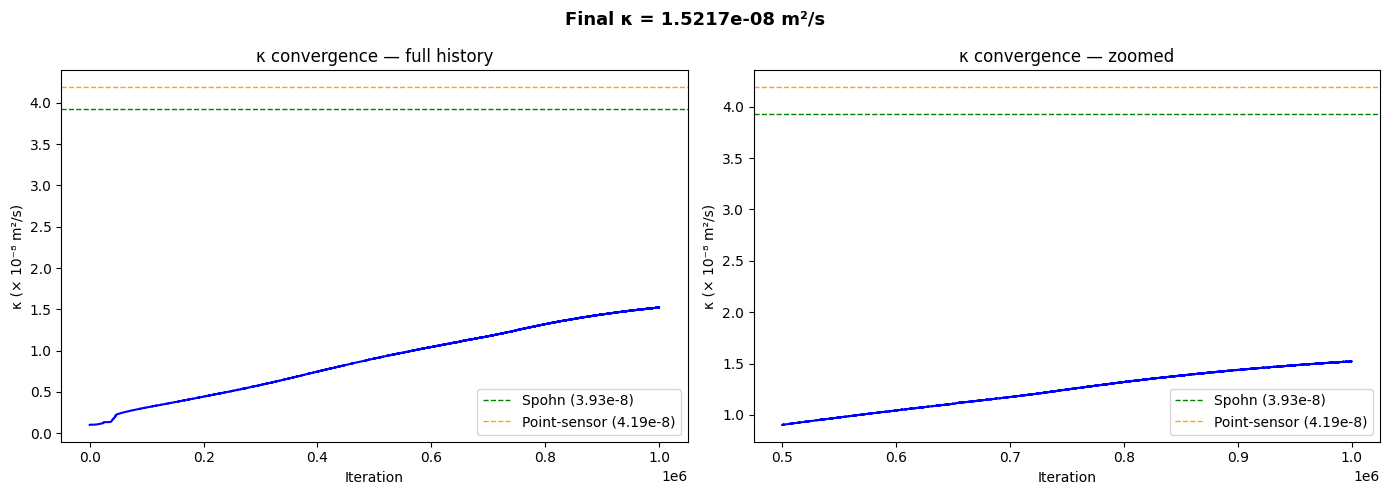

Final κ:          1.5217e-08 m²/s
Spohn reference:  3.93e-8 m²/s  (diff: -61.3%)


In [ ]:


# ── κ convergence plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

iters = jnp.arange(1, len(kappa_history) + 1)

# (a) Full history
axes[0].plot(iters, jnp.array(kappa_history) * 1e8, 'b-', lw=1.5)
axes[0].axhline(3.93, color='green', ls='--', lw=1, label='Spohn (3.93e-8)')
axes[0].axhline(4.19, color='orange', ls='--', lw=1, label='Point-sensor (4.19e-8)')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('κ (× 10⁻⁸ m²/s)')
axes[0].set_title('κ convergence — full history')
axes[0].legend()

# (b) Zoomed on last 50% to see plateau
half = len(kappa_history) // 2
axes[1].plot(iters[half:], jnp.array(kappa_history)[half:] * 1e8, 'b-', lw=1.5)
axes[1].axhline(3.93, color='green', ls='--', lw=1, label='Spohn (3.93e-8)')
axes[1].axhline(4.19, color='orange', ls='--', lw=1, label='Point-sensor (4.19e-8)')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('κ (× 10⁻⁸ m²/s)')
axes[1].set_title('κ convergence — zoomed')
axes[1].legend()

final_kappa = kappa_history[-1]
plt.suptitle(f'Final κ = {final_kappa:.4e} m²/s', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('point_sensor_graphs/kappa_convergence_ps_1e-9_run01.png', dpi=150)
plt.show()

print(f"Final κ:          {final_kappa:.4e} m²/s")
print(f"Spohn reference:  3.93e-8 m²/s  (diff: {(final_kappa - 3.93e-8)/3.93e-8 * 100:+.1f}%)")

In [ ]:
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import openpyxl
import optax

import jax.numpy as jnp

import copy
import pickle

# Problem parameters
depth = 0.4           # domain depth [m]
sol_seconds = 88775.244  # one sol [s]

avg_bottom_temp = 225.6  # average bottom temperature (K)
mole_depth = 0.094  # representative depth for diurnal signal [m]

# TEM-A Sol 1202 = mole temperature over one sol (the warmest sol sampled)
# RAD Sol 511   = surface temperature from radiometer (Spohn's proxy for sol 1202)

wb_diurnal = openpyxl.load_workbook(
    '../resources/data/Mars Soil Temperatures and Thermal Properties from Diurnal Wave data.xlsx',
    data_only=True
)

with open('checkpoints_point_sensor/ps_1e-9_run01.pkl', 'rb') as f:
    checkpoint = pickle.load(f)


kappa = checkpoint['final_kappa']

# --- Mole temperature (TEM-A Sol 1202) ---
ws_tem = wb_diurnal['TEM-A Sol 1202']
ltst_mole, temp_mole = [], []
for row in ws_tem.iter_rows(min_row=2, values_only=True):
    # Column index 6 = 'LTST Conversion step 2' (hours, 0-24)
    # Column index 7 = 'average T15, T16' (Kelvin)
    ltst_val = row[6]
    temp_val = row[7]
    if ltst_val is not None and temp_val is not None:
        try:
            t = float(ltst_val)
            T = float(temp_val)
            if 0 <= t <= 24 and 200 < T < 260:
                ltst_mole.append(t)
                temp_mole.append(T)
        except (ValueError, TypeError):
            pass


# --- Surface temperature (RAD Sol 511) ---
ws_rad = wb_diurnal['RAD SOL 511 D']
ltst_surf, temp_surf = [], []
for row in ws_rad.iter_rows(min_row=2, values_only=True):
    # Column index 4 = 'LTST converted' (hours)
    # Column index 5 = 'FOV 2 Temperature converted' (Kelvin)
    try:
        t = float(row[4])
        T = float(row[5])
        if 0 <= t <= 24 and 150 < T < 350:
            ltst_surf.append(t)
            temp_surf.append(T)
    except (ValueError, TypeError):
        pass

# Sort surface data by LTST (it may not be in order)
sorted_surf = sorted(zip(ltst_surf, temp_surf))
ltst_surf = [x[0] for x in sorted_surf]
temp_surf = [x[1] for x in sorted_surf]

# Conversion from hours to seconds for the time points. Make sure it is mapped correctly to the Mars sol time (0-88775.244 seconds)
ltst_mole = [t * sol_seconds / 24 for t in ltst_mole]
ltst_surf = [t * sol_seconds / 24 for t in ltst_surf]


# 1. Boundary Condition points (552 points each edge as we have 552 time points in the surface data)
n_surface = len(ltst_surf)  # Should be 552

# Surface boundary (x=0):
t_bc_surface = jnp.array(ltst_surf).reshape(-1, 1)  # (552, 1)
x_bc_surface = jnp.zeros((n_surface, 1))  # (552, 1)

u_bc_surface = jnp.array(temp_surf).reshape(-1, 1)  # (552, 1)

# Bottom boundary (x=depth):
t_bc_bottom = jnp.linspace(0, sol_seconds, n_surface).reshape(-1, 1)  # (552, 1)
x_bc_bottom = jnp.ones((n_surface, 1)) * depth

u_bc_bottom = jnp.ones((n_surface, 1)) * avg_bottom_temp  # (552, 1)

# Combine them:
t_bc = jnp.concatenate([t_bc_surface, t_bc_bottom])
x_bc = jnp.concatenate([x_bc_surface, x_bc_bottom])
u_bc = jnp.concatenate([u_bc_surface, u_bc_bottom])


# 2. Physics collocation points (100 * 100 = 10,000 points)
key = random.PRNGKey(0)
key1, key2 = random.split(key)
t_physics = random.uniform(key1, (10000, 1), minval=0, maxval=sol_seconds)
x_physics = random.uniform(key2, (10000, 1), minval=0, maxval=depth)


# 3. Data points for Data Loss (5550 points)
# We can use the mole temperature data as additional data points inside the domain (not just at the boundaries). This will help guide the network to learn the correct solution.

t_data = jnp.array(ltst_mole).reshape(-1, 1)
x_data = jnp.ones((len(ltst_mole), 1)) * mole_depth
u_data = jnp.array(temp_mole).reshape(-1, 1)


# Normalise the data so the network only sees values of order 1. This helps with training stability and convergence. We will need to un-normalise the predictions later to compare with the original data.

# Normalisation parameters
t_min, t_max = 0.0, sol_seconds
x_min, x_max = 0.0, depth
u_min, u_max = 185.0, 300.0  # Based on the range of temperatures in the data

def normalize_t(t): return ( t - t_min) / (t_max - t_min)
def normalize_x(x): return ( x - x_min) / (x_max - x_min)
def normalize_u(u): return ( u - u_min) / (u_max - u_min)

def unnormalize_u(u_norm): return u_norm * (u_max - u_min) + u_min

# Normalize all data
t_bc = normalize_t(t_bc)
x_bc = normalize_x(x_bc)
u_bc = normalize_u(u_bc)

t_physics = normalize_t(t_physics)
x_physics = normalize_x(x_physics)

t_data = normalize_t(t_data)
x_data = normalize_x(x_data)
u_data = normalize_u(u_data)

#Normalize kappa as well (since it appears in the physics residual)
def normalize_kappa(kappa):
    return kappa * (t_max - t_min) / ((x_max - x_min)**2)

# Neural Network

def init_network_params(layer_sizes, key):
    """
    Initialize parameters for a fully connected network.

    Args:
        layer_sizes: List of layer sizes, e.g., [2, 32, 32, 32, 1]
                    (input_dim, hidden1, hidden2, hidden3, output_dim)
        key: JAX random key for initialization

    Returns:
        params: idctionary containging the network list of dictionaries and log_kappa
    """
    # Split random key for each layer
    keys = random.split(key, len(layer_sizes))

    params = {}

    network = []
    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]

        # Split key for weights and biases
        w_key, b_key = random.split(keys[i])

        # Xavier initialization for weights
        network.append({
            'w': random.normal(w_key, (n_in, n_out)) * jnp.sqrt(2.0 / n_in),
            'b': jnp.zeros(n_out)
        })

    params['network'] = network
    params['log_kappa'] = jnp.log(kappa)  # Learn log(kappa) to ensure positivity

    return params


def network(params, x):
    """
    Forward pass through the network.

    Args:
        params: List of layer parameters (from init_network_params)
        x: Input array, shape (batch_size, input_dim)

    Returns:
        Output array, shape (batch_size, output_dim)
    """
    # Process all hidden layers (all but last)


    for layer in params['network'][:-1]:
        # Linear transformation: x @ W + b
        x = jnp.dot(x, layer['w']) + layer['b']
        # Activation function
        x = jnp.tanh(x)

    # Output layer (no activation)
    final_layer = params['network'][-1]
    x = jnp.dot(x, final_layer['w']) + final_layer['b']

    return x


# Calculate Residual

def physics_residual_single(params, t_point, x_point):

    def u(t_val, x_val):
        tx_in = jnp.array([[t_val, x_val]])
        return network(params, tx_in)[0, 0]

    du_dt = grad(u, argnums=0)(t_point, x_point)

    d2u_dx2 = grad(grad(u, argnums = 1), argnums=1)(t_point, x_point)

    kappa_eff = normalize_kappa(jnp.exp(params['log_kappa']))  # Ensure positivity

    return du_dt / kappa_eff - d2u_dx2


# Vectorize to handle all physics points at once
# So vmap will call physics_residual_single 10000 times, once for each (t, x) pair, keeping params fixed.
physics_residual_batch = vmap(physics_residual_single, in_axes=(None, 0, 0))


# Initialize network
key = random.PRNGKey(123)
layer_sizes = [2, 64, 64, 64, 64, 1]  # 2 inputs (t, x), 1 output (u)
params = checkpoint['params']

# Initialize optimizer
learning_rate = 1e-3
schedule = optax.piecewise_constant_schedule(init_value=learning_rate, boundaries_and_scales={60000: 0.1})
optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(params)


@jit
def update_step(params, opt_state,
                t_bc, x_bc, u_bc, t_physics, x_physics, t_data, x_data, u_data):

    def loss_fn(params):

        # 1. Boundary Condition Loss
        tx_bc = jnp.concatenate([t_bc, x_bc], axis=1)
        u_pred_bc = network(params, tx_bc)
        bc_loss = jnp.mean((u_pred_bc - u_bc)**2)

        # 2. Physics Loss
        physics_residuals = physics_residual_batch(params,
                                                t_physics.ravel(), # (10000,) not (10000, 1)
                                                x_physics.ravel()) # (10000,) not (10000, 1)
        physics_loss = jnp.mean(physics_residuals**2) # Physics residual is of 10000 points.

        # 3. Data Loss
        tx_data = jnp.concatenate([t_data, x_data], axis=1)
        u_pred_data = network(params, tx_data)
        data_loss = jnp.mean((u_pred_data - u_data)**2)

        return  bc_loss * 100 + physics_loss + data_loss * 50, (bc_loss, physics_loss, data_loss)

        # Compute loss and gradients
    (loss_val, individual_loss), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)

    # Update parameters
    updates, new_opt_state = optimizer.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)

    return new_params, new_opt_state, loss_val, individual_loss


# Training parameters
num_iterations = 500000
save_every = 150  # Save every 150 iterations
print_every = 1000

# Storage for snapshots
snapshots = []
snapshot_iterations = []

# Prepare physics points (flatten for vmap)
t_phys_flat = t_physics.ravel()
x_phys_flat = x_physics.ravel()

# Training loop
losses = []
losses_bc = []
losses_phys = []
losses_data = []
kappa_history = []
for i in range(num_iterations):
    params, opt_state, loss, individual_loss = update_step(
        params, opt_state,
        t_bc, x_bc, u_bc,
        t_phys_flat, x_phys_flat,
        t_data, x_data, u_data
    )

    losses.append(loss)
    losses_bc.append(individual_loss[0])
    losses_phys.append(individual_loss[1])
    losses_data.append(individual_loss[2])
    kappa_history.append(float(jnp.exp(params['log_kappa'])))


    # Save snapshot every 150 iterations
    if (i + 1) % save_every == 0:
        # Make a copy of params (important!)
        snapshots.append(copy.deepcopy(params))
        snapshot_iterations.append(i + 1)


    if (i + 1) % print_every == 0:
        print(f"Iteration {i+1}/{num_iterations}, Loss: {loss:.6f}")
        print(f"  BC Loss: {individual_loss[0]:.6f}, Physics Loss: {individual_loss[1]:.6f}, Data Loss: {individual_loss[2]:.6f}")
        print(f"  Current kappa: {jnp.exp(params['log_kappa']):.2e} m^2/s")


checkpoint = {
    # Learned parameters
    'params': jax.device_get(params),
    'opt_state': jax.device_get(opt_state),

    # Loss histories
    'losses': [float(l) for l in losses],
    'losses_bc': [float(l) for l in losses_bc],
    'losses_phys': [float(l) for l in losses_phys],
    'losses_data': [float(l) for l in losses_data],
    'kappa_history': kappa_history,

    # Snapshots for animation
    'snapshots': [jax.device_get(s) for s in snapshots],
    'snapshot_iterations': snapshot_iterations,

    # Training config (so you remember what produced this)
    'num_iterations': num_iterations,
    'layer_sizes': layer_sizes,
    'learning_rate': learning_rate,
    'final_kappa': float(jnp.exp(params['log_kappa'])),
}

with open('checkpoints_point_sensor/ps_1e-9_run02.pkl', 'wb') as f:
    pickle.dump(checkpoint, f)

print(f"Checkpoint saved. Final kappa: {jnp.exp(params['log_kappa']):.2e}")



Iteration 1000/500000, Loss: 0.015269
  BC Loss: 0.000007, Physics Loss: 0.001079, Data Loss: 0.000269
  Current kappa: 1.52e-08 m^2/s
Iteration 2000/500000, Loss: 0.020847
  BC Loss: 0.000013, Physics Loss: 0.005821, Data Loss: 0.000275
  Current kappa: 1.52e-08 m^2/s
Iteration 3000/500000, Loss: 0.017102
  BC Loss: 0.000008, Physics Loss: 0.002978, Data Loss: 0.000267
  Current kappa: 1.52e-08 m^2/s
Iteration 4000/500000, Loss: 0.016965
  BC Loss: 0.000007, Physics Loss: 0.002868, Data Loss: 0.000267
  Current kappa: 1.52e-08 m^2/s
Iteration 5000/500000, Loss: 0.019866
  BC Loss: 0.000010, Physics Loss: 0.005468, Data Loss: 0.000268
  Current kappa: 1.52e-08 m^2/s
Iteration 6000/500000, Loss: 0.018933
  BC Loss: 0.000008, Physics Loss: 0.004731, Data Loss: 0.000267
  Current kappa: 1.53e-08 m^2/s
Iteration 7000/500000, Loss: 0.028501
  BC Loss: 0.000009, Physics Loss: 0.014263, Data Loss: 0.000266
  Current kappa: 1.53e-08 m^2/s
Iteration 8000/500000, Loss: 0.032009
  BC Loss: 0.0000

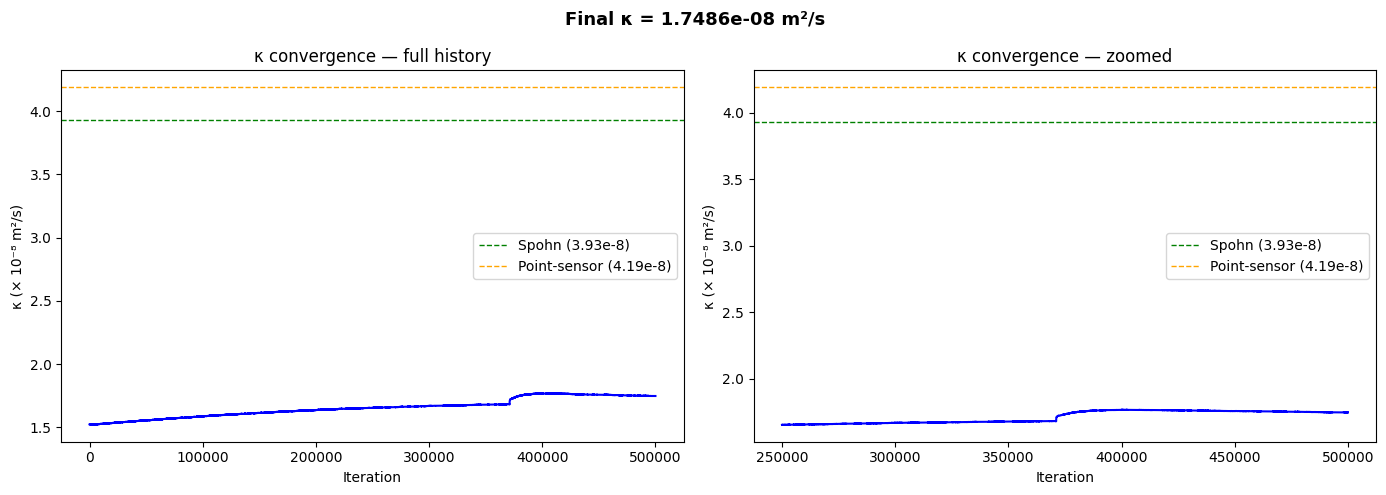

Final κ:          1.7486e-08 m²/s
Spohn reference:  3.93e-8 m²/s  (diff: -55.5%)


In [ ]:


# ── κ convergence plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

iters = jnp.arange(1, len(kappa_history) + 1)

# (a) Full history
axes[0].plot(iters, jnp.array(kappa_history) * 1e8, 'b-', lw=1.5)
axes[0].axhline(3.93, color='green', ls='--', lw=1, label='Spohn (3.93e-8)')
axes[0].axhline(4.19, color='orange', ls='--', lw=1, label='Point-sensor (4.19e-8)')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('κ (× 10⁻⁸ m²/s)')
axes[0].set_title('κ convergence — full history')
axes[0].legend()

# (b) Zoomed on last 50% to see plateau
half = len(kappa_history) // 2
axes[1].plot(iters[half:], jnp.array(kappa_history)[half:] * 1e8, 'b-', lw=1.5)
axes[1].axhline(3.93, color='green', ls='--', lw=1, label='Spohn (3.93e-8)')
axes[1].axhline(4.19, color='orange', ls='--', lw=1, label='Point-sensor (4.19e-8)')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('κ (× 10⁻⁸ m²/s)')
axes[1].set_title('κ convergence — zoomed')
axes[1].legend()

final_kappa = kappa_history[-1]
plt.suptitle(f'Final κ = {final_kappa:.4e} m²/s', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('point_sensor_graphs/kappa_convergence_ps_1e-9_run02.png', dpi=150)
plt.show()

print(f"Final κ:          {final_kappa:.4e} m²/s")
print(f"Spohn reference:  3.93e-8 m²/s  (diff: {(final_kappa - 3.93e-8)/3.93e-8 * 100:+.1f}%)")

In [ ]:
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import openpyxl
import optax

import jax.numpy as jnp

import copy
import pickle

# Problem parameters
depth = 0.4           # domain depth [m]
sol_seconds = 88775.244  # one sol [s]

avg_bottom_temp = 225.6  # average bottom temperature (K)
mole_depth = 0.094  # representative depth for diurnal signal [m]

# TEM-A Sol 1202 = mole temperature over one sol (the warmest sol sampled)
# RAD Sol 511   = surface temperature from radiometer (Spohn's proxy for sol 1202)

wb_diurnal = openpyxl.load_workbook(
    '../resources/data/Mars Soil Temperatures and Thermal Properties from Diurnal Wave data.xlsx',
    data_only=True
)

with open('checkpoints_point_sensor/ps_1e-9_run02.pkl', 'rb') as f:
    checkpoint = pickle.load(f)


kappa = checkpoint['final_kappa']

# --- Mole temperature (TEM-A Sol 1202) ---
ws_tem = wb_diurnal['TEM-A Sol 1202']
ltst_mole, temp_mole = [], []
for row in ws_tem.iter_rows(min_row=2, values_only=True):
    # Column index 6 = 'LTST Conversion step 2' (hours, 0-24)
    # Column index 7 = 'average T15, T16' (Kelvin)
    ltst_val = row[6]
    temp_val = row[7]
    if ltst_val is not None and temp_val is not None:
        try:
            t = float(ltst_val)
            T = float(temp_val)
            if 0 <= t <= 24 and 200 < T < 260:
                ltst_mole.append(t)
                temp_mole.append(T)
        except (ValueError, TypeError):
            pass


# --- Surface temperature (RAD Sol 511) ---
ws_rad = wb_diurnal['RAD SOL 511 D']
ltst_surf, temp_surf = [], []
for row in ws_rad.iter_rows(min_row=2, values_only=True):
    # Column index 4 = 'LTST converted' (hours)
    # Column index 5 = 'FOV 2 Temperature converted' (Kelvin)
    try:
        t = float(row[4])
        T = float(row[5])
        if 0 <= t <= 24 and 150 < T < 350:
            ltst_surf.append(t)
            temp_surf.append(T)
    except (ValueError, TypeError):
        pass

# Sort surface data by LTST (it may not be in order)
sorted_surf = sorted(zip(ltst_surf, temp_surf))
ltst_surf = [x[0] for x in sorted_surf]
temp_surf = [x[1] for x in sorted_surf]

# Conversion from hours to seconds for the time points. Make sure it is mapped correctly to the Mars sol time (0-88775.244 seconds)
ltst_mole = [t * sol_seconds / 24 for t in ltst_mole]
ltst_surf = [t * sol_seconds / 24 for t in ltst_surf]


# 1. Boundary Condition points (552 points each edge as we have 552 time points in the surface data)
n_surface = len(ltst_surf)  # Should be 552

# Surface boundary (x=0):
t_bc_surface = jnp.array(ltst_surf).reshape(-1, 1)  # (552, 1)
x_bc_surface = jnp.zeros((n_surface, 1))  # (552, 1)

u_bc_surface = jnp.array(temp_surf).reshape(-1, 1)  # (552, 1)

# Bottom boundary (x=depth):
t_bc_bottom = jnp.linspace(0, sol_seconds, n_surface).reshape(-1, 1)  # (552, 1)
x_bc_bottom = jnp.ones((n_surface, 1)) * depth

u_bc_bottom = jnp.ones((n_surface, 1)) * avg_bottom_temp  # (552, 1)

# Combine them:
t_bc = jnp.concatenate([t_bc_surface, t_bc_bottom])
x_bc = jnp.concatenate([x_bc_surface, x_bc_bottom])
u_bc = jnp.concatenate([u_bc_surface, u_bc_bottom])


# 2. Physics collocation points (100 * 100 = 10,000 points)
key = random.PRNGKey(0)
key1, key2 = random.split(key)
t_physics = random.uniform(key1, (10000, 1), minval=0, maxval=sol_seconds)
x_physics = random.uniform(key2, (10000, 1), minval=0, maxval=depth)


# 3. Data points for Data Loss (5550 points)
# We can use the mole temperature data as additional data points inside the domain (not just at the boundaries). This will help guide the network to learn the correct solution.

t_data = jnp.array(ltst_mole).reshape(-1, 1)
x_data = jnp.ones((len(ltst_mole), 1)) * mole_depth
u_data = jnp.array(temp_mole).reshape(-1, 1)


# Normalise the data so the network only sees values of order 1. This helps with training stability and convergence. We will need to un-normalise the predictions later to compare with the original data.

# Normalisation parameters
t_min, t_max = 0.0, sol_seconds
x_min, x_max = 0.0, depth
u_min, u_max = 185.0, 300.0  # Based on the range of temperatures in the data

def normalize_t(t): return ( t - t_min) / (t_max - t_min)
def normalize_x(x): return ( x - x_min) / (x_max - x_min)
def normalize_u(u): return ( u - u_min) / (u_max - u_min)

def unnormalize_u(u_norm): return u_norm * (u_max - u_min) + u_min

# Normalize all data
t_bc = normalize_t(t_bc)
x_bc = normalize_x(x_bc)
u_bc = normalize_u(u_bc)

t_physics = normalize_t(t_physics)
x_physics = normalize_x(x_physics)

t_data = normalize_t(t_data)
x_data = normalize_x(x_data)
u_data = normalize_u(u_data)

#Normalize kappa as well (since it appears in the physics residual)
def normalize_kappa(kappa):
    return kappa * (t_max - t_min) / ((x_max - x_min)**2)

# Neural Network

def init_network_params(layer_sizes, key):
    """
    Initialize parameters for a fully connected network.

    Args:
        layer_sizes: List of layer sizes, e.g., [2, 32, 32, 32, 1]
                    (input_dim, hidden1, hidden2, hidden3, output_dim)
        key: JAX random key for initialization

    Returns:
        params: idctionary containging the network list of dictionaries and log_kappa
    """
    # Split random key for each layer
    keys = random.split(key, len(layer_sizes))

    params = {}

    network = []
    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]

        # Split key for weights and biases
        w_key, b_key = random.split(keys[i])

        # Xavier initialization for weights
        network.append({
            'w': random.normal(w_key, (n_in, n_out)) * jnp.sqrt(2.0 / n_in),
            'b': jnp.zeros(n_out)
        })

    params['network'] = network
    params['log_kappa'] = jnp.log(kappa)  # Learn log(kappa) to ensure positivity

    return params


def network(params, x):
    """
    Forward pass through the network.

    Args:
        params: List of layer parameters (from init_network_params)
        x: Input array, shape (batch_size, input_dim)

    Returns:
        Output array, shape (batch_size, output_dim)
    """
    # Process all hidden layers (all but last)


    for layer in params['network'][:-1]:
        # Linear transformation: x @ W + b
        x = jnp.dot(x, layer['w']) + layer['b']
        # Activation function
        x = jnp.tanh(x)

    # Output layer (no activation)
    final_layer = params['network'][-1]
    x = jnp.dot(x, final_layer['w']) + final_layer['b']

    return x


# Calculate Residual

def physics_residual_single(params, t_point, x_point):

    def u(t_val, x_val):
        tx_in = jnp.array([[t_val, x_val]])
        return network(params, tx_in)[0, 0]

    du_dt = grad(u, argnums=0)(t_point, x_point)

    d2u_dx2 = grad(grad(u, argnums = 1), argnums=1)(t_point, x_point)

    kappa_eff = normalize_kappa(jnp.exp(params['log_kappa']))  # Ensure positivity

    return du_dt / kappa_eff - d2u_dx2


# Vectorize to handle all physics points at once
# So vmap will call physics_residual_single 10000 times, once for each (t, x) pair, keeping params fixed.
physics_residual_batch = vmap(physics_residual_single, in_axes=(None, 0, 0))


# Initialize network
key = random.PRNGKey(123)
layer_sizes = [2, 64, 64, 64, 64, 1]  # 2 inputs (t, x), 1 output (u)
params = checkpoint['params']

# Initialize optimizer
learning_rate = 1e-3
schedule = optax.piecewise_constant_schedule(init_value=learning_rate, boundaries_and_scales={60000: 0.1})
optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(params)


@jit
def update_step(params, opt_state,
                t_bc, x_bc, u_bc, t_physics, x_physics, t_data, x_data, u_data):

    def loss_fn(params):

        # 1. Boundary Condition Loss
        tx_bc = jnp.concatenate([t_bc, x_bc], axis=1)
        u_pred_bc = network(params, tx_bc)
        bc_loss = jnp.mean((u_pred_bc - u_bc)**2)

        # 2. Physics Loss
        physics_residuals = physics_residual_batch(params,
                                                t_physics.ravel(), # (10000,) not (10000, 1)
                                                x_physics.ravel()) # (10000,) not (10000, 1)
        physics_loss = jnp.mean(physics_residuals**2) # Physics residual is of 10000 points.

        # 3. Data Loss
        tx_data = jnp.concatenate([t_data, x_data], axis=1)
        u_pred_data = network(params, tx_data)
        data_loss = jnp.mean((u_pred_data - u_data)**2)

        return  bc_loss * 100 + physics_loss + data_loss * 50, (bc_loss, physics_loss, data_loss)

        # Compute loss and gradients
    (loss_val, individual_loss), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)

    # Update parameters
    updates, new_opt_state = optimizer.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)

    return new_params, new_opt_state, loss_val, individual_loss


# Training parameters
num_iterations = 200000
save_every = 150  # Save every 150 iterations
print_every = 1000

# Storage for snapshots
snapshots = []
snapshot_iterations = []

# Prepare physics points (flatten for vmap)
t_phys_flat = t_physics.ravel()
x_phys_flat = x_physics.ravel()

# Training loop
losses = []
losses_bc = []
losses_phys = []
losses_data = []
kappa_history = []
for i in range(num_iterations):
    params, opt_state, loss, individual_loss = update_step(
        params, opt_state,
        t_bc, x_bc, u_bc,
        t_phys_flat, x_phys_flat,
        t_data, x_data, u_data
    )

    losses.append(loss)
    losses_bc.append(individual_loss[0])
    losses_phys.append(individual_loss[1])
    losses_data.append(individual_loss[2])
    kappa_history.append(float(jnp.exp(params['log_kappa'])))


    # Save snapshot every 150 iterations
    if (i + 1) % save_every == 0:
        # Make a copy of params (important!)
        snapshots.append(copy.deepcopy(params))
        snapshot_iterations.append(i + 1)


    if (i + 1) % print_every == 0:
        print(f"Iteration {i+1}/{num_iterations}, Loss: {loss:.6f}")
        print(f"  BC Loss: {individual_loss[0]:.6f}, Physics Loss: {individual_loss[1]:.6f}, Data Loss: {individual_loss[2]:.6f}")
        print(f"  Current kappa: {jnp.exp(params['log_kappa']):.2e} m^2/s")


checkpoint = {
    # Learned parameters
    'params': jax.device_get(params),
    'opt_state': jax.device_get(opt_state),

    # Loss histories
    'losses': [float(l) for l in losses],
    'losses_bc': [float(l) for l in losses_bc],
    'losses_phys': [float(l) for l in losses_phys],
    'losses_data': [float(l) for l in losses_data],
    'kappa_history': kappa_history,

    # Snapshots for animation
    'snapshots': [jax.device_get(s) for s in snapshots],
    'snapshot_iterations': snapshot_iterations,

    # Training config (so you remember what produced this)
    'num_iterations': num_iterations,
    'layer_sizes': layer_sizes,
    'learning_rate': learning_rate,
    'final_kappa': float(jnp.exp(params['log_kappa'])),
}

with open('checkpoints_point_sensor/ps_1e-9_run03.pkl', 'wb') as f:
    pickle.dump(checkpoint, f)

print(f"Checkpoint saved. Final kappa: {jnp.exp(params['log_kappa']):.2e}")



Iteration 1000/200000, Loss: 0.021034
  BC Loss: 0.000005, Physics Loss: 0.007315, Data Loss: 0.000265
  Current kappa: 1.75e-08 m^2/s
Iteration 2000/200000, Loss: 0.017503
  BC Loss: 0.000006, Physics Loss: 0.003540, Data Loss: 0.000268
  Current kappa: 1.75e-08 m^2/s
Iteration 3000/200000, Loss: 0.018048
  BC Loss: 0.000005, Physics Loss: 0.004270, Data Loss: 0.000266
  Current kappa: 1.75e-08 m^2/s
Iteration 4000/200000, Loss: 0.027847
  BC Loss: 0.000034, Physics Loss: 0.009422, Data Loss: 0.000301
  Current kappa: 1.75e-08 m^2/s
Iteration 5000/200000, Loss: 0.049767
  BC Loss: 0.000088, Physics Loss: 0.023683, Data Loss: 0.000346
  Current kappa: 1.75e-08 m^2/s
Iteration 6000/200000, Loss: 0.018774
  BC Loss: 0.000004, Physics Loss: 0.005061, Data Loss: 0.000266
  Current kappa: 1.75e-08 m^2/s
Iteration 7000/200000, Loss: 0.021909
  BC Loss: 0.000007, Physics Loss: 0.007716, Data Loss: 0.000270
  Current kappa: 1.75e-08 m^2/s
Iteration 8000/200000, Loss: 0.022679
  BC Loss: 0.0000

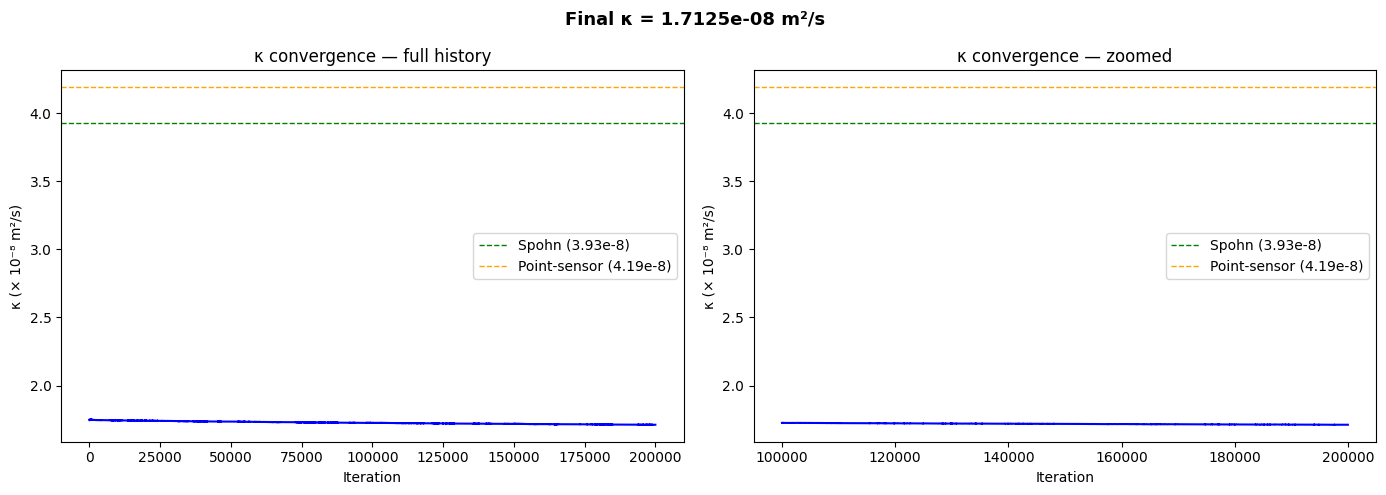

Final κ:          1.7125e-08 m²/s
Spohn reference:  3.93e-8 m²/s  (diff: -56.4%)


In [ ]:


# ── κ convergence plot ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

iters = jnp.arange(1, len(kappa_history) + 1)

# (a) Full history
axes[0].plot(iters, jnp.array(kappa_history) * 1e8, 'b-', lw=1.5)
axes[0].axhline(3.93, color='green', ls='--', lw=1, label='Spohn (3.93e-8)')
axes[0].axhline(4.19, color='orange', ls='--', lw=1, label='Point-sensor (4.19e-8)')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('κ (× 10⁻⁸ m²/s)')
axes[0].set_title('κ convergence — full history')
axes[0].legend()

# (b) Zoomed on last 50% to see plateau
half = len(kappa_history) // 2
axes[1].plot(iters[half:], jnp.array(kappa_history)[half:] * 1e8, 'b-', lw=1.5)
axes[1].axhline(3.93, color='green', ls='--', lw=1, label='Spohn (3.93e-8)')
axes[1].axhline(4.19, color='orange', ls='--', lw=1, label='Point-sensor (4.19e-8)')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('κ (× 10⁻⁸ m²/s)')
axes[1].set_title('κ convergence — zoomed')
axes[1].legend()

final_kappa = kappa_history[-1]
plt.suptitle(f'Final κ = {final_kappa:.4e} m²/s', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('point_sensor_graphs/kappa_convergence_ps_1e-9_run03.png', dpi=150)
plt.show()

print(f"Final κ:          {final_kappa:.4e} m²/s")
print(f"Spohn reference:  3.93e-8 m²/s  (diff: {(final_kappa - 3.93e-8)/3.93e-8 * 100:+.1f}%)")